In [1]:
!pip install rapidfuzz

In [2]:
!pip install matplotlib seaborn

# HYBRID RECOMMENDER SYSTEM


Destination standardization summary:
Original unique destinations: 82
Standardized unique destinations: 76
Creating feature vectors...
Saving reduced matrix...
['Trip ID', 'Destination', 'Start date', 'End date', 'Duration (days)', 'Traveler name', 'Traveler age', 'Traveler gender', 'Traveler nationality', 'Accommodation type', 'Accommodation cost', 'Transportation type', 'Transportation cost', 'Rating', 'normalized_destination', 'Season', 'destination_type', 'User ID']
normalized_destination  accra ghana  addis ababa ethiopia  amsterdam  \
normalized_destination                                                 
accra ghana                1.000000              0.915853   0.857455   
addis ababa ethiopia       0.915853              1.000000   0.699817   
amsterdam                  0.857455              0.699817   1.000000   
amsterdam netherlands      0.865528              0.717871   0.975806   
athens greece              0.891871              0.638915   0.858561   

normalized_destinat

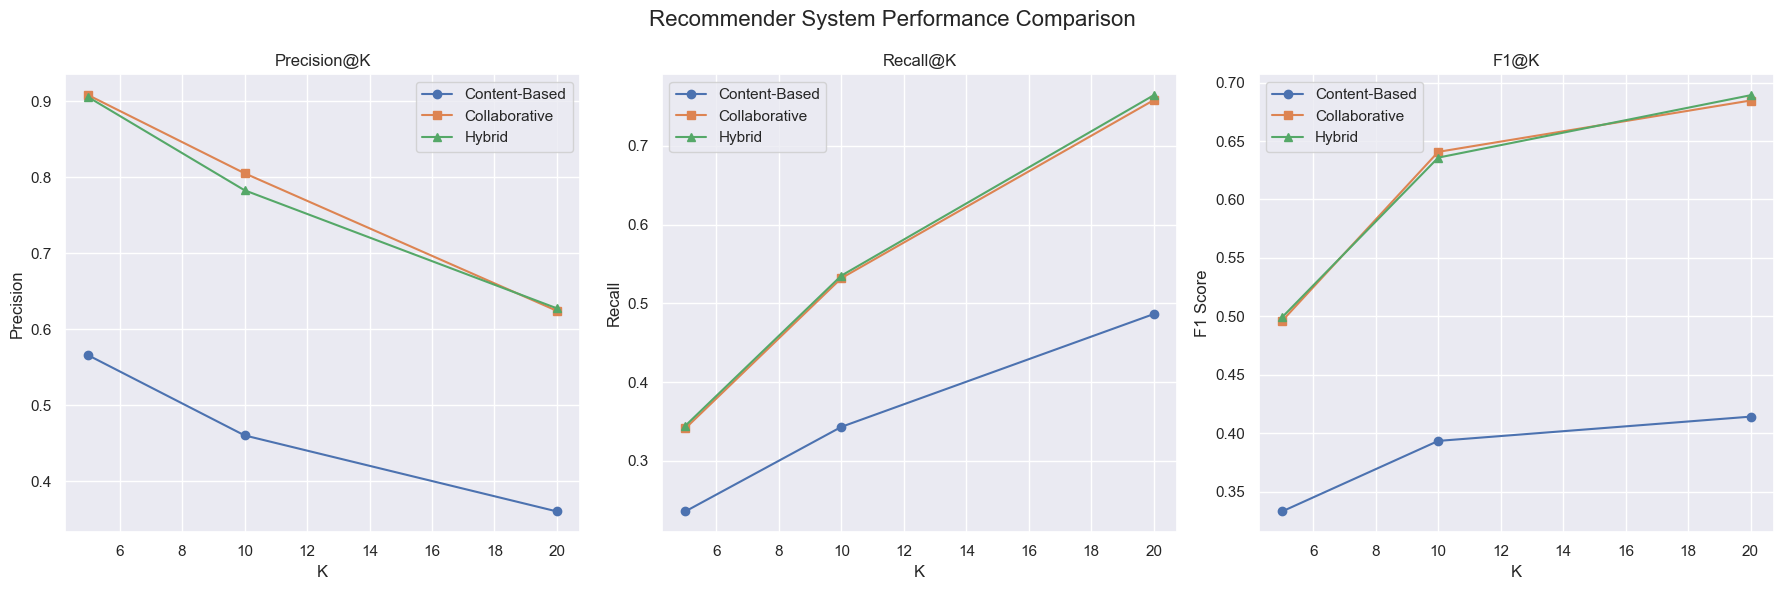

Saved average performance plot to 'average_performance.png'


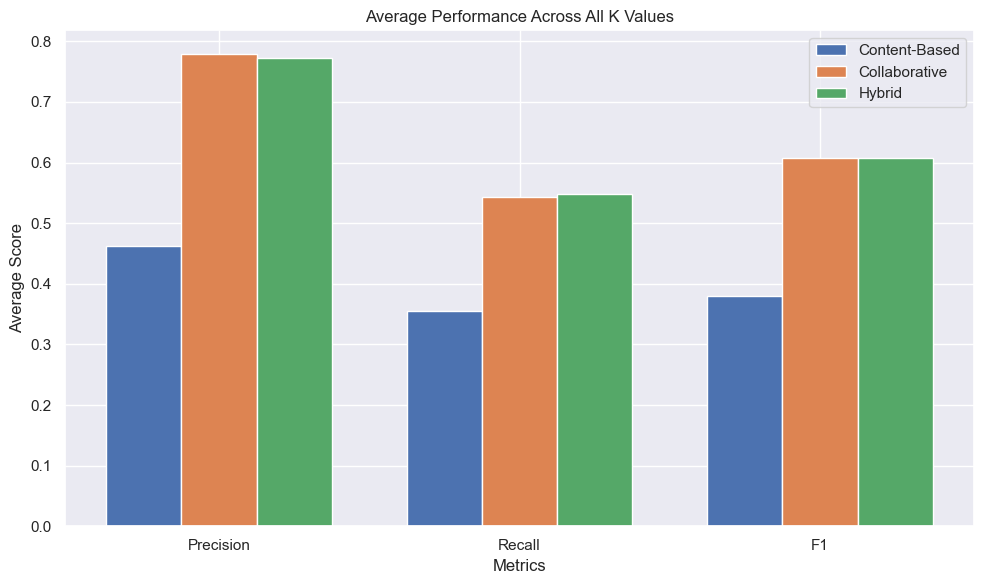


Generating detailed metrics table...

Saved detailed metrics table to 'recommender_metrics.csv'

Detailed Metrics Table:
       System       K Precision@K Recall@K   F1@K
Content-Based       5      0.5658   0.2359 0.3330
Collaborative       5      0.9079   0.3412 0.4960
       Hybrid       5      0.9053   0.3446 0.4992
Content-Based      10      0.4605   0.3433 0.3934
Collaborative      10      0.8053   0.5321 0.6408
       Hybrid      10      0.7829   0.5353 0.6358
Content-Based      20      0.3605   0.4865 0.4141
Collaborative      20      0.6243   0.7580 0.6847
       Hybrid      20      0.6276   0.7642 0.6892
Content-Based Average      0.4623   0.3552 0.3802
Collaborative Average      0.7792   0.5438 0.6072
       Hybrid Average      0.7719   0.5480 0.6081

Final Comparison of All Systems:

Content-Based Filtering (CBF) Results:

K=5:
Precision@K: 0.5658
Recall@K: 0.2359
F1@K: 0.3330

K=10:
Precision@K: 0.4605
Recall@K: 0.3433
F1@K: 0.3934

K=20:
Precision@K: 0.3605
Recall@K: 0.48

In [ ]:
#Import and load the dataset
import pandas as pd

df = pd.read_csv('final_travel_dataset_100000.csv')
df.head()
from rapidfuzz import fuzz, process

# Step 1: Normalize destinations (lowercase, strip whitespace and punctuation)
def normalize_destination(dest):
    """
    Enhanced destination normalization to handle duplicates and city-country combinations
    """
    # Convert to lowercase and strip whitespace
    dest = dest.lower().strip()
    
    # Remove common punctuation and separators
    dest = dest.replace(",", " ").replace(".", " ").replace("-", " ").replace("  ", " ")
    
    # Split into parts
    parts = dest.split()
    
    # Common country abbreviations mapping
    country_mapping = {
        'uk': 'united kingdom',
        'usa': 'united states',
        'uae': 'united arab emirates',
        'sa': 'south africa',
        'nz': 'new zealand',
        'us': 'united states',
        'ind': 'india',
        'indo': 'indonesia',
        'thai': 'thailand',
        'jpn': 'japan',
        'chn': 'china',
        'aus': 'australia',
        'ger': 'germany',
        'fra': 'france',
        'ita': 'italy',
        'esp': 'spain'
    }
    
    # Common country names to standardize
    country_standardization = {
        'france': 'france',
        'japan': 'japan',
        'thailand': 'thailand',
        'china': 'china',
        'australia': 'australia',
        'italy': 'italy',
        'spain': 'spain',
        'germany': 'germany',
        'united states': 'united states',
        'united kingdom': 'united kingdom',
        'india': 'india',
        'indonesia': 'indonesia',
        'malaysia': 'malaysia',
        'singapore': 'singapore',
        'vietnam': 'vietnam',
        'cambodia': 'cambodia',
        'laos': 'laos',
        'myanmar': 'myanmar',
        'philippines': 'philippines',
        'south korea': 'south korea',
        'north korea': 'north korea',
        'russia': 'russia',
        'brazil': 'brazil',
        'argentina': 'argentina',
        'mexico': 'mexico',
        'canada': 'canada'
    }
    
    # Common words to remove
    remove_words = {'city', 'town', 'village', 'region', 'district', 'province', 
                   'state', 'republic', 'of', 'the', 'island', 'islands', 'beach',
                   'resort', 'area', 'region', 'capital', 'metropolitan'}
    
    # Process parts
    cleaned_parts = []
    for part in parts:
        # Replace abbreviations
        if part in country_mapping:
            cleaned_parts.extend(country_mapping[part].split())
        # Standardize country names
        elif part in country_standardization:
            cleaned_parts.append(country_standardization[part])
        # Keep if not in remove words
        elif part not in remove_words:
            cleaned_parts.append(part)
    
    # Join back together
    return ' '.join(cleaned_parts)

def categorize_destination(dest):
    """
    Standalone function to categorize destinations with enhanced categories
    """
    dest = str(dest).lower()
    categories = {
        'Beach': ['beach', 'island', 'coast', 'bali', 'phuket', 'gold coast', 'cancun', 'fiji', 
                 'hawaii', 'maldives', 'seychelles', 'boracay', 'mauritius', 'caribbean'],
        'Mountain': ['mountain', 'hill', 'alps', 'everest', 'kilimanjaro', 'andes', 'rockies', 
                    'himalayas', 'fuji', 'sierra', 'pyrenees'],
        'City': ['kuala lumpur', 'singapore', 'hong kong', 'seoul', 'zurich', 'lisbon', 'amsterdam',
                'city', 'york', 'london', 'paris', 'tokyo', 'dubai', 'san francisco', 'toronto', 
                'osaka', 'berlin', 'madrid', 'milan', 'stockholm', 'copenhagen', 'vienna', 
                'melbourne', 'sydney'],
        'Historic': ['greece', 'barcelona', 'berlin', 'budapest', 'prague', 'rome', 'vienna', 
                    'athens', 'petra', 'angkor wat', 'machu picchu', 'pompeii', 'acropolis', 
                    'colosseum', 'archaeological'],
        'Nature': ['accra', 'ababa', 'nairobi', 'cairo', 'marrakech', 'cape town', 'serengeti', 
                  'amazon', 'galapagos', 'yellowstone', 'grand canyon', 'yosemite', 'kruger', 
                  'safari', 'national park'],
        'Entertainment': ['vegas', 'ibiza', 'miami', 'rio', 'monaco', 'macau', 'disney', 
                        'universal', 'carnival'],
        'Wine & Culinary': ['tuscany', 'provence', 'napa', 'bordeaux', 'chianti', 'burgundy', 
                           'champagne', 'culinary']
    }
    
    for category, keywords in categories.items():
        if any(word in dest for word in keywords):
            return category
    return 'Other'



def create_destination_mapping(df):
    """
    Create mapping for similar destinations using fuzzy matching
    """
    from rapidfuzz import fuzz, process
    
    # Get unique destinations
    unique_dests = df['Destination'].unique()
    dest_map = {}
    
    # First pass: normalize all destinations
    normalized_dests = {dest: normalize_destination(dest) for dest in unique_dests}
    
    # Second pass: group similar destinations
    for dest in unique_dests:
        normalized = normalized_dests[dest]
        
        if normalized not in dest_map:
            # Find similar destinations
            matches = process.extract(
                normalized,
                [d for d in normalized_dests.values() if d != normalized],
                scorer=fuzz.token_sort_ratio,
                limit=5
            )
            
            # Group destinations with high similarity
            similar_dests = [dest]
            for match, score, _ in matches:
                if score > 90:  # Threshold for considering destinations as same
                    similar_dests.extend([
                        d for d in unique_dests 
                        if normalized_dests[d] == match
                    ])
            
            # Choose the most detailed name as the canonical form
            canonical = max(similar_dests, key=len)
            
            # Map all similar destinations to the canonical form
            for d in similar_dests:
                dest_map[d] = canonical
        
    return dest_map

# Apply the improved normalization to the dataframe
def standardize_destinations(df):
    """
    Standardize destinations in the dataframe with improved handling
    """
    # Create a copy of the dataframe
    df_clean = df.copy()
    
    # Apply normalization
    df_clean['normalized_destination'] = df_clean['Destination'].apply(normalize_destination)
    
    # Print summary of changes
    print("\nDestination standardization summary:")
    print(f"Original unique destinations: {len(df['Destination'].unique())}")
    print(f"Standardized unique destinations: {len(df_clean['normalized_destination'].unique())}")
    
    return df_clean

# Usage example:
df = standardize_destinations(df)

# Step 2: Find fuzzy matches and map them to a single name
unique_dests = df['normalized_destination'].unique()
dest_map = {}

for dest in unique_dests:
    if not dest_map:  # if first entry, just add it
        dest_map[dest] = dest
        continue

    match_result = process.extractOne(dest, dest_map.keys(), scorer=fuzz.token_sort_ratio)
    
    if match_result:
        match, score, _ = match_result
        if score > 90:
            dest_map[dest] = dest_map[match]
        else:
            dest_map[dest] = dest  # new unique entry
    else:
        dest_map[dest] = dest  # fallback if no match at all

# Step 3: Replace normalized names in original df
df
# Check for missing values after conversion
missing_values = df.isnull().sum()

# Drop unnecessary columns or transform them as needed
# Replace 'Traveler name' with a unique user ID
df['User ID'] = df['Traveler name'].astype('category').cat.codes

# Convert categorical columns to category dtype (for encoding later)
categorical_cols = ['normalized_destination', 'Traveler gender', 'Traveler nationality', 
                    'Accommodation type', 'Transportation type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Display cleaned data and missing values
df.head(), missing_values



#Import and load the dataset
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix, save_npz, load_npz
import os
from datetime import datetime
import tkinter as tk
from tkinter import ttk, messagebox, scrolledtext

df = pd.read_csv('final_travel_dataset_100000.csv')
df.head()

"""!pip install rapidfuzz"""

from rapidfuzz import fuzz, process

def explain_collaborative_recommendations(self, recommendations):
    if isinstance(recommendations, str):
        return recommendations

df['normalized_destination'] = df['Destination'].apply(normalize_destination)

# Step 2: Find fuzzy matches and map them to a single name
unique_dests = df['normalized_destination'].unique()
dest_map = {}

for dest in unique_dests:
    if not dest_map:  # if first entry, just add it
        dest_map[dest] = dest
        continue

    match_result = process.extractOne(dest, dest_map.keys(), scorer=fuzz.token_sort_ratio)
    
    if match_result:
        match, score, _ = match_result
        if score > 90:
            dest_map[dest] = dest_map[match]
        else:
            dest_map[dest] = dest  # new unique entry
    else:
        dest_map[dest] = dest  # fallback if no match at all

# Step 3: Replace normalized names in original df
df['normalized_destination'] = df['normalized_destination'].map(dest_map)

# Clean and preprocess the dataset
def preprocess_data(df):
    """
    Initial data cleaning and preprocessing with enhanced functionality
    """
    df = df.copy()
    
    # Convert costs to numeric
    df['Accommodation cost'] = pd.to_numeric(df['Accommodation cost'], errors='coerce')
    df['Transportation cost'] = pd.to_numeric(df['Transportation cost'], errors='coerce')
    
    # Fill missing values with mean
    df['Accommodation cost'] = df['Accommodation cost'].fillna(df['Accommodation cost'].mean())
    df['Transportation cost'] = df['Transportation cost'].fillna(df['Transportation cost'].mean())
    
    # Convert Start date to datetime and extract season
    try:
        df['Start date'] = pd.to_datetime(df['Start date'], errors='coerce')
        df['Season'] = df['Start date'].dt.month.map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
    except:
        df['Season'] = 'Unknown'
    
    # Add normalized destination if not exists
    if 'normalized_destination' not in df.columns:
        df['normalized_destination'] = df['Destination'].apply(normalize_destination)
    
    # Add destination type if not exists
    if 'destination_type' not in df.columns:
        df['destination_type'] = df['Destination'].apply(categorize_destination)
    
    return df

# Apply preprocessing
df = preprocess_data(df)

# Create feature vectors
def create_feature_vectors(df):
    """Create feature vectors using TF-IDF and dimensionality reduction"""
    # Combine text features
    text_features = df[['normalized_destination', 'Accommodation type', 
                       'Transportation type', 'Season']].astype(str).apply(
        lambda x: ' '.join(x), axis=1
    )
    
    # Create TF-IDF vectors
    tfidf = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 1),
        max_features=1000,
        dtype=np.float32
    )
    
    # Fit and transform
    tfidf_matrix = tfidf.fit_transform(text_features)
    
    # Apply dimensionality reduction
    svd = TruncatedSVD(n_components=100, random_state=42)
    reduced_matrix = svd.fit_transform(tfidf_matrix)
    
    return reduced_matrix, svd

# Create and save feature vectors
print("Creating feature vectors...")
feature_matrix, svd = create_feature_vectors(df)

# Save the reduced matrix
print("Saving reduced matrix...")
np.save('reduced_matrix.npy', feature_matrix)


# Show the dimension of dataframe
df.shape


# Check for missing values after conversion
missing_values = df.isnull().sum()

# Drop unnecessary columns or transform them as needed
# Replace 'Traveler name' with a unique user ID
df['User ID'] = df['Traveler name'].astype('category').cat.codes

# Convert categorical columns to category dtype (for encoding later)
categorical_cols = ['normalized_destination', 'Traveler gender', 'Traveler nationality', 
                    'Accommodation type', 'Transportation type']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Display cleaned data and missing values
df.head(), missing_values

# Fill missing values with the mean of each cost column
df['Accommodation cost'] = df['Accommodation cost'].fillna(df['Accommodation cost'].mean())
df['Transportation cost'] = df['Transportation cost'].fillna(df['Transportation cost'].mean())

# Verify no missing values remain
df.isnull().sum()

#data cleaning and prepared ready!!!!!!!!!!!!!!!!
print(df.columns.tolist())


# 1. Convert Start date to datetime
df['Start date'] = pd.to_datetime(df['Start date'], errors='coerce')


# 2. Fix: Safe fillna for Categorical columns
from pandas.api.types import CategoricalDtype

def safe_fillna(df, column, value=""):
    if isinstance(df[column].dtype, CategoricalDtype):
        if value not in df[column].cat.categories:
            df[column] = df[column].cat.add_categories([value])
        df[column] = df[column].fillna(value)
    else:
        df[column] = df[column].fillna(value)


# 3. Apply fillna
df['normalized_destination'] = df['normalized_destination'].astype('object').fillna("")
df['Accommodation type'] = df['Accommodation type'].astype('object').fillna("")
df['Transportation type'] = df['Transportation type'].astype('object').fillna("")
df['Season'] = df['Season'].astype('object').fillna("Unknown")


# Add feature weighting to give more importance to certain features
def get_weighted_features(df):
    # Create a copy of the dataframe
    weighted_df = df.copy()
    
    # Add weights to different features
    weighted_df['combined_features'] = (
        df['normalized_destination'] + " " +  # Base weight
        df['Accommodation type'] + " " +      # Base weight
        df['Transportation type'] + " " +     # Base weight
        df['Season'] + " " +                  # Base weight
        df['Accommodation type'] + " " +      # Double weight for accommodation
        df['Transportation type'] + " " +     # Double weight for transportation
        df['Season']                          # Double weight for season
    )
    return weighted_df

# Apply weighted features
df = get_weighted_features(df)

# Add sentiment analysis based on ratings
def add_sentiment_features(df):
    # Create sentiment categories based on ratings
    df['sentiment'] = pd.cut(df['Rating'], 
                            bins=[0, 2, 3, 4, 5],
                            labels=['Very Negative', 'Negative', 'Positive', 'Very Positive'])
    
    # Add sentiment to combined features
    df['combined_features'] = df['combined_features'] + " " + df['sentiment'].astype(str)
    return df

# Apply sentiment analysis
df = add_sentiment_features(df)

# Create TF-IDF matrix
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000
)
tfidf_matrix = tfidf.fit_transform(df['combined_features'])



import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1. Reload or reference your cleaned DataFrame (df_clean)
#    If you already ran the cleaning steps, just ensure df_clean exists.
#    Otherwise, re-run your cleaning code:

df_clean = df.copy()  # if not done yet
essential_cols = ['normalized_destination', 'Traveler name', 'Traveler age', 'Traveler gender', 
                  'Traveler nationality','Accommodation type', 'Accommodation cost', 
                  'Transportation type', 'Transportation cost']
df_clean = df_clean.dropna(subset=essential_cols).copy()  # drop NaNs & make explicit copy

# Correct .loc usage to avoid SettingWithCopyWarning
df_clean.loc[:, 'Accommodation cost'] = pd.to_numeric(
    df_clean['Accommodation cost'], errors='coerce')
df_clean.loc[:, 'Transportation cost'] = pd.to_numeric(
    df_clean['Transportation cost'], errors='coerce')

# Then drop any rows where conversion failed
df_clean = df_clean.dropna(
    subset=['Accommodation cost', 'Transportation cost']).reset_index(drop=True)


# 2. Re-create encoded_df
encoded_df = df_clean.copy()
categorical_cols = ['Traveler name', 'Traveler gender', 'Traveler nationality',
                    'Accommodation type', 'Transportation type']  # no included 'Destination'

# turn categories into numbers
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le


# 3. Build item_features for CBF
item_features = encoded_df.groupby('normalized_destination').agg({
    'Accommodation type': 'first',
    'Transportation type': 'first',
    'Accommodation cost': 'mean',
    'Transportation cost': 'mean',
    'Duration (days)': 'mean'
}).reset_index()  # Destination 是原文

#Scales numeric features so they're on the same range before calculating similarity.
scaler = StandardScaler()
item_features[['Accommodation cost', 'Transportation cost', 'Duration (days)']] = \
    scaler.fit_transform(item_features[['Accommodation cost', 'Transportation cost', 'Duration (days)']])

# 4. Compute cosine similarity matrix
#Creates a matrix where each cell is a similarity score 
#between two destinations based on numeric + encoded features.
feature_matrix = item_features.drop(columns='normalized_destination')
item_sim = cosine_similarity(feature_matrix)
item_sim_df = pd.DataFrame(item_sim, 
                           index=item_features['normalized_destination'], 
                           columns=item_features['normalized_destination'])

# Now item_sim_df exists for recommendations
print(item_sim_df.head())

def get_similar_destinations(dest_name, top_n=10):
    if dest_name not in item_sim_df.index:
        return f"Destination '{dest_name}' not found in the dataset."

    sims = item_sim_df.loc[dest_name].sort_values(ascending=False)
    sims = sims.drop(index=dest_name)  # Remove itself

    top_similar = sims.head(top_n)

    result_df = item_features[item_features['normalized_destination'].isin(top_similar.index)].copy()
    result_df['similarity_score'] = result_df['normalized_destination'].map(top_similar)
    # Remove the old 'Similarity Score' column if it exists
    if 'Similarity Score' in result_df.columns:
        result_df = result_df.drop(columns=['Similarity Score'])
    result_df = result_df.sort_values(by='similarity_score', ascending=False).reset_index(drop=True)

    return result_df


from sklearn.decomposition import NMF
from scipy.sparse import csr_matrix
from sklearn.preprocessing import MinMaxScaler



def engineer_features_for_content(df):
    """
    Enhanced feature engineering with improved robustness and combined functionality
    """
    df_content = df.copy()
    
    # Convert costs to numeric and handle outliers
    for cost_col in ['Accommodation cost', 'Transportation cost']:
        df_content[cost_col] = pd.to_numeric(df_content[cost_col], errors='coerce')
        # Handle outliers using IQR method
        Q1 = df_content[cost_col].quantile(0.25)
        Q3 = df_content[cost_col].quantile(0.75)
        IQR = Q3 - Q1
        df_content[cost_col] = df_content[cost_col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
    
    # Enhanced price categorization
    df_content['total_cost'] = df_content['Accommodation cost'] + df_content['Transportation cost']
    df_content['cost_per_day'] = df_content['total_cost'] / df_content['Duration (days)']
    
    try:
        df_content['price_category'] = pd.qcut(
            df_content['cost_per_day'],
            q=5,
            labels=['Budget', 'Economy', 'Mid-range', 'Luxury', 'Ultra-luxury']
        )
    except ValueError:
        df_content['price_category'] = pd.cut(
            df_content['cost_per_day'],
            bins=5,
            labels=['Budget', 'Economy', 'Mid-range', 'Luxury', 'Ultra-luxury']
        )
    
    # Enhanced trip type categorization
    df_content['trip_type'] = pd.cut(
        df_content['Duration (days)'],
        bins=[-float('inf'), 3, 7, 14, float('inf')],
        labels=['Weekend Trip', 'Short Trip', 'Medium Trip', 'Long Trip']
    )
    
    # Enhanced season detection
    try:
        df_content['Start date'] = pd.to_datetime(df_content['Start date'])
        df_content['season'] = df_content['Start date'].dt.month.map({
            12: 'Winter', 1: 'Winter', 2: 'Winter',
            3: 'Spring', 4: 'Spring', 5: 'Spring',
            6: 'Summer', 7: 'Summer', 8: 'Summer',
            9: 'Fall', 10: 'Fall', 11: 'Fall'
        })
    except:
        df_content['season'] = 'Unknown'
    
    # Apply destination categorization if not exists
    if 'destination_type' not in df_content.columns:
        df_content['destination_type'] = df_content['Destination'].apply(categorize_destination)
    
    # Add travel style based on combination of features
    def get_travel_style(row):
        if row['price_category'] in ['Luxury', 'Ultra-luxury']:
            return 'Luxury'
        elif row['destination_type'] in ['Nature', 'Mountain']:
            return 'Adventure'
        elif row['destination_type'] in ['Beach']:
            return 'Leisure'
        elif row['destination_type'] in ['City', 'Historic']:
            return 'Cultural'
        return 'Standard'
    
    df_content['travel_style'] = df_content.apply(get_travel_style, axis=1)
    
    # Create feature vectors using TF-IDF
    feature_cols = [
        'normalized_destination',
        'destination_type',
        'Accommodation type',
        'Transportation type',
        'season',
        'price_category',
        'trip_type',
        'travel_style'
    ]
    
    # Ensure all features are strings before joining
    df_content['feature_vector'] = df_content[feature_cols].astype(str).apply(
        lambda x: ' '.join(x), axis=1
    )
    
    # Fill missing values with appropriate defaults
    df_content = df_content.fillna({
        'season': 'Unknown',
        'price_category': 'Mid-range',
        'trip_type': 'Medium Trip',
        'destination_type': 'Other',
        'travel_style': 'Standard',
        'cost_per_day': df_content['cost_per_day'].median()
    })
    
    return df_content

def explain_recommendations(recommendations):
    """
    Enhanced explanation function with more detailed similarity reasoning
    """
    if isinstance(recommendations, str):
        return recommendations
    
    output = "\nTop Recommendations:\n" + "=" * 20 + "\n"
    
    for _, rec in recommendations.iterrows():
        output += f"\nRecommended {rec['destination']}\n"
        output += "-" * len(f"Recommended {rec['destination']}") + "\n"
        output += f"Type: {rec['destination_type']}\n"
        output += f"Rating: {rec['rating']}/5\n"
        output += f"Similarity Score: {rec['similarity_score']:.2f}\n"
        
        # Enhanced similarity reasoning
        similarities = []
        
        # Destination type similarities
        if rec['destination_type'] == 'Beach':
            similarities.append("beach destination perfect for relaxation")
        elif rec['destination_type'] == 'Mountain':
            similarities.append("mountainous region ideal for adventure")
        elif rec['destination_type'] == 'City':
            similarities.append("vibrant urban destination")
        elif rec['destination_type'] == 'Historic':
            similarities.append("rich in cultural heritage")
        elif rec['destination_type'] == 'Nature':
            similarities.append("natural wilderness destination")
        elif rec['destination_type'] == 'Entertainment':
            similarities.append("entertainment and nightlife hub")
        elif rec['destination_type'] == 'Wine & Culinary':
            similarities.append("renowned for food and wine")

        # Price category similarities
        if rec['price_category'] == 'Budget':
            similarities.append("budget-friendly option")
        elif rec['price_category'] == 'Mid-range':
            similarities.append("similar moderate price range")
        elif rec['price_category'] == 'Luxury':
            similarities.append("luxury travel experience")
        elif rec['price_category'] == 'Ultra-luxury':
            similarities.append("premium luxury destination")

        # Trip duration similarities
        if rec['trip_type'] == 'Weekend Trip':
            similarities.append("perfect for a weekend getaway")
        elif rec['trip_type'] == 'Short Trip':
            similarities.append("ideal for a short vacation")
        elif rec['trip_type'] == 'Medium Trip':
            similarities.append("similar trip duration")
        elif rec['trip_type'] == 'Long Trip':
            similarities.append("extended stay destination")

        # Seasonal similarities
        season_desc = {
            'Spring': "beautiful spring weather",
            'Summer': "perfect summer destination",
            'Fall': "lovely autumn atmosphere",
            'Winter': "winter travel destination"
        }
        if rec['season'] in season_desc:
            similarities.append(season_desc[rec['season']])
            
        if similarities:
            output += f"Similar because: {', '.join(similarities)}\n"
        
        # Enhanced travel details
        output += f"\nTravel Details:"
        output += f"\n- Best Time to Visit: {rec['season']}"
        output += f"\n- Recommended Stay: {rec['trip_type']}"
        output += f"\n- Transportation: {rec['transportation_type']}"
        output += f"\n- Accommodation: {rec['accommodation_type']} ({rec['price_category']})"
        output += f"\n- Estimated Daily Cost: ${rec['cost_per_day']:.2f}"
        
        # Add specific destination highlights based on type
        output += "\n\nDestination Highlights:"
        if rec['destination_type'] == 'Beach':
            output += "\n- Beautiful coastlines and water activities"
            output += "\n- Perfect for relaxation and water sports"
        elif rec['destination_type'] == 'Mountain':
            output += "\n- Stunning mountain landscapes"
            output += "\n- Great for hiking and outdoor activities"
        elif rec['destination_type'] == 'City':
            output += "\n- Rich urban culture and attractions"
            output += "\n- Shopping and dining opportunities"
        elif rec['destination_type'] == 'Historic':
            output += "\n- Ancient sites and cultural landmarks"
            output += "\n- Rich historical significance"
        elif rec['destination_type'] == 'Nature':
            output += "\n- Natural wonders and wildlife"
            output += "\n- Outdoor adventure opportunities"
        elif rec['destination_type'] == 'Entertainment':
            output += "\n- Vibrant nightlife and entertainment"
            output += "\n- World-class shows and attractions"
        elif rec['destination_type'] == 'Wine & Culinary':
            output += "\n- Exceptional food and wine experiences"
            output += "\n- Local culinary traditions"
            
        output += "\n" + "-" * 50 + "\n"
    
    return output

def analyze_destination(df, destination):
    """
    Analyze the characteristics of a destination to help with recommendations
    """
    df_content = engineer_features_for_content(df)
    
    # Check if destination exists
    dest_matches = df_content[df_content['normalized_destination'] == destination]
    if len(dest_matches) == 0:
        print(f"\nError: Destination '{destination}' not found in the dataset.")
        print("Available destinations include:")
        print(", ".join(df_content['normalized_destination'].unique()[:10]))
        if len(df_content['normalized_destination'].unique()) > 10:
            print("... and more")
        return None
    
    dest_data = dest_matches.iloc[0]
    
    print(f"\nDestination Analysis: {dest_data['Destination']}")
    print("=" * 40)
    print(f"Destination Type: {dest_data['destination_type']}")
    print(f"Typical Price Range: {dest_data['price_category']}")
    print(f"Common Trip Duration: {dest_data['trip_type']}")
    print(f"Popular Season: {dest_data['season']}")
    print(f"Average Cost Per Day: ${dest_data['cost_per_day']:.2f}")
    print(f"Average Rating: {dest_data['Rating']}/5")
    
    # Get similar destinations by type
    similar_type = df_content[
        (df_content['destination_type'] == dest_data['destination_type']) & 
        (df_content['normalized_destination'] != destination)
    ]['Destination'].unique()[:3]
    
    if len(similar_type) > 0:
        print(f"\nSimilar destinations by type: {', '.join(similar_type)}")
    
    return dest_data

class ContentBasedRecommender:
    def __init__(self, df):
        """
        Initialize content-based recommender with memory-efficient approach
        """
        print("\nInitializing Content-Based Recommender...")
        self.df = df.copy()
        
        # Normalize destinations
        print("Normalizing destinations...")
        self.df['normalized_destination'] = self.df['Destination'].apply(normalize_destination)
        
        # Add required fields if they don't exist
        if 'destination_type' not in self.df.columns:
            print("Adding destination types...")
            self.df['destination_type'] = self.df['Destination'].apply(categorize_destination)
        
        if 'trip_type' not in self.df.columns:
            print("Adding trip types...")
            self.df['trip_type'] = pd.cut(
                self.df['Duration (days)'],
                bins=[-float('inf'), 3, 7, 14, float('inf')],
                labels=['Weekend Trip', 'Short Trip', 'Medium Trip', 'Long Trip']
            )
        
        if 'price_category' not in self.df.columns:
            print("Adding price categories...")
            try:
                total_cost = self.df['Accommodation cost'] + self.df['Transportation cost']
                cost_per_day = total_cost / self.df['Duration (days)']
                self.df['price_category'] = pd.qcut(
                    cost_per_day,
                    q=5,
                    labels=['Budget', 'Economy', 'Mid-range', 'Luxury', 'Ultra-luxury']
                )
            except:
                self.df['price_category'] = 'Mid-range'
        
        # Initialize TF-IDF variables
        self.tfidf = None
        self.tfidf_matrix = None
        self.feature_cols = [
            'normalized_destination',
            'destination_type',
            'Accommodation type',
            'Transportation type',
            'Season',  # Note the capital S
            'price_category',
            'trip_type'
        ]
        
        print(f"Feature columns: {self.feature_cols}")
        
        # Prepare data
        self.prepare_data()
        print("Content-Based Recommender initialization complete!")
        
    def prepare_data(self):
        """
        Prepare data for content-based recommendations with memory optimization
        """
        try:
            print("\nPreparing content-based recommender data...")
            
            # Create feature vectors with reduced dimensionality
            print("Creating feature vectors...")
            self.df['feature_vector'] = self.df[self.feature_cols].astype(str).apply(
                lambda x: ' '.join(x), axis=1
            )
            
            # Create TF-IDF matrix with reduced features
            print("Creating TF-IDF matrix...")
            self.tfidf = TfidfVectorizer(
                stop_words='english',
                ngram_range=(1, 2),  # Use both unigrams and bigrams
                max_features=5000     # Limit number of features
            )
            self.tfidf_matrix = self.tfidf.fit_transform(self.df['feature_vector'])
            
            print(f"TF-IDF matrix shape: {self.tfidf_matrix.shape}")
            print("Feature preparation complete!")
            
        except Exception as e:
            print(f"Error in prepare_data: {str(e)}")
            import traceback
            traceback.print_exc()
            
    def get_recommendations_v2(self, destination, n_recommendations=5, min_rating=3.5, filters=None):
        """
        Enhanced content-based recommendation system with improved diversity and filtering
        """
        try:
            print(f"\nGetting recommendations for destination: {destination}")
            print(f"Parameters: n_recommendations={n_recommendations}, min_rating={min_rating}")
            if filters:
                print(f"Applied filters: {filters}")
            
            # Get index of the destination
            dest_indices = self.df[self.df['normalized_destination'] == destination].index
            if len(dest_indices) == 0:
                print(f"Destination '{destination}' not found in dataset")
                return f"Destination '{destination}' not found in dataset."
            
            idx = dest_indices[0]
            print(f"Found destination at index: {idx}")
            
            # Calculate similarities using pre-computed TF-IDF matrix
            print("Calculating similarities...")
            sim_vector = cosine_similarity(self.tfidf_matrix[idx:idx+1], self.tfidf_matrix).flatten()
            sim_scores = list(enumerate(sim_vector))
            
            # Filter and sort recommendations
            seen_destinations = set()
            filtered_scores = []
            
            print("Filtering recommendations...")
            for i, score in sorted(sim_scores, key=lambda x: x[1], reverse=True):
                current_dest = self.df.iloc[i]
                
                # Skip if it's the input destination
                if current_dest['normalized_destination'] == destination:
                    continue
                
                # Skip if we've already seen this destination
                if current_dest['normalized_destination'] in seen_destinations:
                    continue
                
                # Skip if rating is too low
                if current_dest['Rating'] < min_rating:
                    continue
                
                # Apply filters if provided
                if filters:
                    matches_filters = True
                    for key, value in filters.items():
                        if not value:  # Skip empty filter values
                            continue
                            
                        if key == 'destination_type' and value:
                            if str(current_dest['destination_type']).lower() != str(value).lower():
                                matches_filters = False
                                break
                                
                        elif key == 'season' and value:
                            if str(current_dest['Season']).lower() != str(value).lower():
                                matches_filters = False
                                break
                                
                        elif key == 'trip_type' and value:
                            if str(current_dest['trip_type']).lower() != str(value).lower():
                                matches_filters = False
                                break
                                
                        elif key == 'price_category' and value:
                            if str(current_dest['price_category']).lower() != str(value).lower():
                                matches_filters = False
                                break
                                
                    if not matches_filters:
                        continue
                
                filtered_scores.append((i, score))
                seen_destinations.add(current_dest['normalized_destination'])
                
                if len(filtered_scores) >= n_recommendations:
                    break
            
            print(f"Found {len(filtered_scores)} recommendations after filtering")
            
            if not filtered_scores:
                return pd.DataFrame()  # Return empty DataFrame if no recommendations found
            
            # Create recommendations dataframe
            recommendations = []
            for i, score in filtered_scores:
                current_dest = self.df.iloc[i]
                recommendations.append({
                    'destination': current_dest['Destination'],
                    'normalized_destination': current_dest['normalized_destination'],
                    'similarity_score': score,
                    'rating': current_dest['Rating'],
                    'destination_type': current_dest['destination_type'],
                    'season': current_dest['Season'],
                    'trip_type': current_dest['trip_type'],
                    'price_category': current_dest['price_category'],
                    'accommodation_type': current_dest['Accommodation type'],
                    'transportation_type': current_dest['Transportation type']
                })
            
            recommendations_df = pd.DataFrame(recommendations)
            print("Recommendations generated successfully!")
            return recommendations_df
        
        except Exception as e:
            print(f"Error in get_recommendations_v2: {str(e)}")
            import traceback
            traceback.print_exc()
            return f"Error generating recommendations: {str(e)}"

class DestinationCollaborativeFiltering:
    def __init__(self, df):
        """
        Initialize destination-based collaborative filtering with enhanced features
        """
        self.df = df.copy()
        
        # Normalize destinations using the same function as content-based
        self.df['normalized_destination'] = self.df['Destination'].apply(normalize_destination)
        
        # Add required fields for filtering if they don't exist
        if 'destination_type' not in self.df.columns:
            self.df['destination_type'] = self.df['Destination'].apply(categorize_destination)
        
        if 'trip_type' not in self.df.columns:
            self.df['trip_type'] = pd.cut(
                self.df['Duration (days)'],
                bins=[-float('inf'), 3, 7, 14, float('inf')],
                labels=['Weekend Trip', 'Short Trip', 'Medium Trip', 'Long Trip']
            )
        
        if 'price_category' not in self.df.columns:
            try:
                total_cost = self.df['Accommodation cost'] + self.df['Transportation cost']
                cost_per_day = total_cost / self.df['Duration (days)']
                self.df['price_category'] = pd.qcut(
                    cost_per_day,
                    q=5,
                    labels=['Budget', 'Economy', 'Mid-range', 'Luxury', 'Ultra-luxury']
                )
            except:
                self.df['price_category'] = 'Mid-range'
        
        # Convert numeric columns to proper data types
        self.df['Rating'] = pd.to_numeric(self.df['Rating'], errors='coerce')
        if 'Accommodation cost' in self.df.columns:
            self.df['Accommodation cost'] = pd.to_numeric(self.df['Accommodation cost'], errors='coerce')
        if 'Transportation cost' in self.df.columns:
            self.df['Transportation cost'] = pd.to_numeric(self.df['Transportation cost'], errors='coerce')
        if 'Duration (days)' in self.df.columns:
            self.df['Duration (days)'] = pd.to_numeric(self.df['Duration (days)'], errors='coerce')
        
        # Initialize additional attributes
        self.destination_matrix = None
        self.destination_similarity = None
        self.destination_similarity_df = None
        self.destination_features = None
        self.feature_weights = None
        self.popularity_bias = None
    
        # Prepare the similarity matrix
        self.prepare_similarity_matrix()
    
    def prepare_similarity_matrix(self):
        """
        Prepare the destination similarity matrix
        """
        try:
            print("\nPreparing similarity matrix...")
            
            # Create destination features first
            print("Creating destination features...")
            self.destination_features = self.df.groupby('normalized_destination').agg({
                'Rating': 'mean',
                'destination_type': 'first',
                'Season': 'first',  # Note the capital S
                'trip_type': 'first',
                'price_category': 'first',
                'Accommodation type': 'first',
                'Transportation type': 'first'
            }).rename(columns={
                'Rating': 'mean_rating',
                'Accommodation type': 'accommodation_type',
                'Transportation type': 'transportation_type'
            })
            
            print(f"Created features for {len(self.destination_features)} destinations")
            
            if self.destination_features.empty:
                print("Error: No destination features were created")
                return
            
            # Get unique destinations
            destinations = self.destination_features.index.unique()
            print(f"Found {len(destinations)} unique destinations")
            
            # Initialize similarity matrix with float64 dtype
            self.destination_similarity_df = pd.DataFrame(
                index=destinations,
                columns=destinations,
                dtype=np.float64  # Changed from float32 to float64
            )
            
            # Calculate similarity scores
            print("Calculating similarity scores...")
            for dest1 in destinations:
                dest1_features = self.destination_features.loc[dest1]
                
                for dest2 in destinations:
                    if dest1 == dest2:
                        self.destination_similarity_df.loc[dest1, dest2] = 1.0
                        continue
                        
                    if pd.isna(self.destination_similarity_df.loc[dest1, dest2]):
                        dest2_features = self.destination_features.loc[dest2]
                        similarity = self.calculate_destination_similarity(dest1_features, dest2_features)
                        self.destination_similarity_df.loc[dest1, dest2] = similarity
                        self.destination_similarity_df.loc[dest2, dest1] = similarity
            
            print("Similarity matrix preparation completed")
            print(f"Matrix shape: {self.destination_similarity_df.shape}")
            
            # Verify the matrix has values
            if self.destination_similarity_df.empty:
                print("Warning: Similarity matrix is empty!")
            else:
                print("\nSample of similarity matrix:")
                print(self.destination_similarity_df.iloc[:5, :5])
                
        except Exception as e:
            print(f"Error preparing similarity matrix: {str(e)}")
            import traceback
            traceback.print_exc()
            self.destination_similarity_df = None
    
    def get_similar_destinations(self, destination, n_recommendations=5, min_rating=3.5, filters=None):
        """
        Get similar destinations with enhanced diversity and filtering
        """
        try:
            # Ensure similarity matrix is prepared
            if self.destination_similarity_df is None:
                self.prepare_similarity_matrix()
            
            if self.destination_similarity_df is None:
                print("Error: Similarity matrix is None")
                return pd.DataFrame()
            
            print(f"\nFinding similar destinations to: {destination}")
            
            # Normalize input destination name
            destination = destination.strip().lower()
            
            # Check if destination exists in the dataset
            if destination not in self.destination_similarity_df.index:
                print(f"Destination '{destination}' not found in dataset")
                # Try to find similar destinations using fuzzy matching
                from rapidfuzz import process
                matches = process.extract(
                    destination,
                    self.destination_similarity_df.index,
                    scorer=fuzz.token_sort_ratio,
                    limit=5
                )
                if matches:
                    print("Did you mean one of these?")
                    for match, score, _ in matches:
                        print(f"- {match} (similarity: {score}%)")
                return pd.DataFrame()
            
            # Get similarity scores
            similarity_scores = self.destination_similarity_df.loc[destination]
            
            # Get top similar destinations
            similar_destinations = similarity_scores[similarity_scores.index != destination]
            similar_destinations = similar_destinations.sort_values(ascending=False)
            
            # Create recommendations with detailed information
            recommendations = []
            seen_destinations = set()
            
            for dest, similarity in similar_destinations.items():
                # Skip if we've already seen this destination
                if dest in seen_destinations:
                    continue
                    
                # Get destination features
                dest_features = self.destination_features.loc[dest]
                
                # Skip if rating is too low
                if dest_features['mean_rating'] < min_rating:
                    continue
                
                # Create recommendation dict with all available information
                rec = {
                    'destination': dest,
                    'normalized_destination': dest,
                    'similarity_score': similarity,
                    'rating': dest_features['mean_rating'],
                    'destination_type': dest_features['destination_type'],
                    'season': dest_features['Season'],  # Note the capital S
                    'trip_type': dest_features['trip_type'],
                    'price_category': dest_features['price_category'],
                    'accommodation_type': dest_features['accommodation_type'],
                    'transportation_type': dest_features['transportation_type']
                }
                
                # Apply filters if provided and not empty
                if filters:
                    matches_filters = True
                    for key, value in filters.items():
                        if value and key in rec and str(rec[key]).lower() != str(value).lower():
                            matches_filters = False
                            break
                    if not matches_filters:
                        continue
                
                recommendations.append(rec)
                seen_destinations.add(dest)
                
                if len(recommendations) >= n_recommendations:
                    break
            
            recommendations_df = pd.DataFrame(recommendations)
            
            if recommendations_df.empty:
                print("No recommendations found matching the criteria")
                return pd.DataFrame()
            
            print(f"Found {len(recommendations_df)} collaborative recommendations")
            return recommendations_df
            
        except Exception as e:
            print(f"Error in get_similar_destinations: {str(e)}")
            import traceback
            traceback.print_exc()
            return pd.DataFrame()
    
    def create_destination_features(self):
        """
        Create destination features for similarity calculation
        """
        try:
            print("\nCreating destination features...")
            
            # Group by destination and calculate aggregated features
            features = self.df.groupby('normalized_destination').agg({
                'mean_rating': 'mean',
                'destination_type': 'first',
                'season': 'first',
                'trip_type': 'first',
                'price_category': 'first',
                'accommodation_type': lambda x: x.mode().iloc[0] if not x.empty else 'Not specified',
                'transportation_type': lambda x: x.mode().iloc[0] if not x.empty else 'Not specified'
            }).reset_index()
            
            # Set normalized_destination as index
            features.set_index('normalized_destination', inplace=True)
            
            # Convert categorical variables to dummy variables
            categorical_columns = ['destination_type', 'season', 'trip_type', 'price_category', 
                                'accommodation_type', 'transportation_type']
            
            # Create dummy variables for each categorical column
            dummy_features = pd.DataFrame(index=features.index)
            for col in categorical_columns:
                if col in features.columns:
                    dummies = pd.get_dummies(features[col], prefix=col)
                    dummy_features = pd.concat([dummy_features, dummies], axis=1)
            
            # Combine numerical and dummy features
            final_features = pd.concat([
                features[['mean_rating']],
                dummy_features
            ], axis=1)
            
            print(f"Created features for {len(final_features)} destinations")
            print("Feature columns:", final_features.columns.tolist())
            
            if final_features.empty:
                print("Warning: No features were created!")
                return None
                
            return final_features
            
        except Exception as e:
            print(f"Error creating destination features: {str(e)}")
            import traceback
            traceback.print_exc()
            return None

    def calculate_destination_similarity(self, dest1_features, dest2_features):
        """
        Calculate similarity between two destinations based on their features
        """
        try:
            similarity_score = 0.0
            total_weight = 0.0
            
            # Weights for different feature types
            weights = {
                'mean_rating': 0.3,
                'destination_type': 0.2,
                'season': 0.15,
                'trip_type': 0.15,
                'price_category': 0.1,
                'accommodation_type': 0.05,
                'transportation_type': 0.05
            }
            
            # Calculate similarity for each feature
            for feature, weight in weights.items():
                if feature == 'mean_rating':
                    # For numerical features, use normalized difference
                    if feature in dest1_features.index and feature in dest2_features.index:
                        diff = abs(float(dest1_features[feature]) - float(dest2_features[feature]))
                        max_diff = 5.0  # Maximum possible rating difference
                        feature_similarity = 1.0 - (diff / max_diff)
                        similarity_score += feature_similarity * weight
                        total_weight += weight
                else:
                    # For categorical features, exact match = 1, no match = 0
                    if feature in dest1_features.index and feature in dest2_features.index:
                        if str(dest1_features[feature]).lower() == str(dest2_features[feature]).lower():
                            similarity_score += weight
                        total_weight += weight
            
            # Normalize similarity score
            if total_weight > 0:
                final_similarity = similarity_score / total_weight
            else:
                final_similarity = 0.0
            
            return final_similarity
            
        except Exception as e:
            print(f"Error calculating destination similarity: {str(e)}")
            import traceback
            traceback.print_exc()
            return 0.0



def combine_similar_destinations(df):
    """
    Combine similar destinations using fuzzy matching and create a mapping
    """
    from rapidfuzz import fuzz, process
    
    # Get unique normalized destinations
    unique_dests = df['normalized_destination'].unique()
    dest_map = {}
    
    # Create a mapping of original to normalized destinations
    for dest in unique_dests:
        if dest not in dest_map:
            # Find similar destinations
            matches = process.extract(
                dest,
                [d for d in unique_dests if d != dest],
                scorer=fuzz.token_sort_ratio,
                limit=5
            )
            
            # Group destinations with high similarity
            similar_dests = [dest]
            for match, score, _ in matches:
                if score > 90:  # High similarity threshold
                    similar_dests.append(match)
            
            # Choose the most detailed name as the canonical form
            canonical = max(similar_dests, key=len)
            
            # Map all similar destinations to the canonical form
            for d in similar_dests:
                dest_map[d] = canonical
    
    # Apply the mapping to the dataframe
    df['canonical_destination'] = df['normalized_destination'].map(dest_map)
    
    # Print summary of changes
    print("\nDestination standardization summary:")
    print(f"Original unique destinations: {len(df['Destination'].unique())}")
    print(f"Normalized unique destinations: {len(df['normalized_destination'].unique())}")
    print(f"Canonical unique destinations: {len(df['canonical_destination'].unique())}")
    
    return df

class WeightedHybridRecommender:
    def __init__(self, df, content_weight=0.3, collaborative_weight=0.7):
        """
        Initialize weighted hybrid recommender system with enhanced features
        """
        # Create a copy of the dataframe and ensure required columns exist
        self.df = df.copy()
        
        # Apply enhanced destination normalization
        self.df['normalized_destination'] = self.df['Destination'].apply(normalize_destination)
        
        # Ensure destination_type exists
        if 'destination_type' not in self.df.columns:
            self.df['destination_type'] = self.df['Destination'].apply(categorize_destination)
        
        # Ensure trip_type exists
        if 'trip_type' not in self.df.columns:
            self.df['trip_type'] = pd.cut(
                self.df['Duration (days)'],
                bins=[-float('inf'), 3, 7, 14, float('inf')],
                labels=['Weekend Trip', 'Short Trip', 'Medium Trip', 'Long Trip']
            )
        
        # Ensure price_category exists
        if 'price_category' not in self.df.columns:
            try:
                total_cost = self.df['Accommodation cost'] + self.df['Transportation cost']
                cost_per_day = total_cost / self.df['Duration (days)']
                self.df['price_category'] = pd.qcut(
                    cost_per_day,
                    q=5,
                    labels=['Budget', 'Economy', 'Mid-range', 'Luxury', 'Ultra-luxury']
                )
            except:
                self.df['price_category'] = 'Mid-range'
        
        # Initialize weights with dynamic adjustment capability
        self.base_content_weight = content_weight
        self.base_collaborative_weight = collaborative_weight
        self.content_weight = content_weight
        self.collaborative_weight = collaborative_weight
        
        # Initialize recommenders
        print("\nInitializing Content-Based Recommender...")
        self.content_recommender = ContentBasedRecommender(self.df)
        
        print("\nInitializing Collaborative Filtering Recommender...")
        self.collaborative_recommender = DestinationCollaborativeFiltering(self.df)
        
        # Initialize filter options
        self.destination_types = sorted(self.df['destination_type'].unique().tolist())
        self.seasons = sorted(self.df['Season'].unique().tolist())
        self.trip_types = sorted(self.df['trip_type'].unique().tolist())
        self.price_categories = sorted(self.df['price_category'].unique().tolist())
        
        # Initialize performance tracking
        self.performance_history = {
            'content': {'precision': [], 'recall': [], 'f1': []},
            'collaborative': {'precision': [], 'recall': [], 'f1': []},
            'hybrid': {'precision': [], 'recall': [], 'f1': []}
        }
        
        # Initialize destination statistics
        self.destination_stats = self.calculate_destination_statistics()
        
        print("\nInitialized filter options:")
        print(f"Destination types: {self.destination_types}")
        print(f"Seasons: {self.seasons}")
        print(f"Trip types: {self.trip_types}")
        print(f"Price categories: {self.price_categories}")
    
    def calculate_destination_statistics(self):
        """
        Calculate comprehensive destination statistics
        """
        stats = self.df.groupby('normalized_destination').agg({
            'Rating': ['mean', 'count', 'std'],
            'Duration (days)': ['mean', 'std'],
            'Accommodation cost': 'mean',
            'Transportation cost': 'mean',
            'destination_type': 'first',
            'Season': lambda x: x.mode().iloc[0] if not x.empty else 'Unknown',
            'trip_type': lambda x: x.mode().iloc[0] if not x.empty else 'Unknown',
            'price_category': lambda x: x.mode().iloc[0] if not x.empty else 'Unknown'
        }).reset_index()
        
        stats.columns = [
            'normalized_destination',
            'avg_rating', 'rating_count', 'rating_std',
            'avg_duration', 'duration_std',
            'avg_accommodation_cost',
            'avg_transportation_cost',
            'destination_type',
            'popular_season',
            'popular_trip_type',
            'popular_price_category'
        ]
        
        # Calculate reliability scores
        stats['rating_reliability'] = stats['rating_count'] / stats['rating_count'].max()
        stats['duration_reliability'] = 1 - (stats['duration_std'] / stats['duration_std'].max())
        
        # Calculate overall quality score
        stats['quality_score'] = (
            0.4 * (stats['avg_rating'] / 5.0) +
            0.3 * stats['rating_reliability'] +
            0.2 * stats['duration_reliability'] +
            0.1 * (1 - (stats['avg_accommodation_cost'] + stats['avg_transportation_cost']) / 
                  (stats['avg_accommodation_cost'].max() + stats['avg_transportation_cost'].max()))
        )
        
        return stats.set_index('normalized_destination')
    
    def adjust_weights(self, content_performance, collaborative_performance):
        """
        Dynamically adjust weights based on recent performance with momentum
        """
        # Calculate performance ratios with momentum
        content_ratio = (content_performance['precision'] + content_performance['recall']) / 2
        collaborative_ratio = (collaborative_performance['precision'] + collaborative_performance['recall']) / 2
        
        # Add momentum from previous weights
        momentum = 0.3  # Increased momentum factor
        content_ratio = (1 - momentum) * content_ratio + momentum * self.content_weight
        collaborative_ratio = (1 - momentum) * collaborative_ratio + momentum * self.collaborative_weight
        
        # Normalize ratios
        total = content_ratio + collaborative_ratio
        if total > 0:
            self.content_weight = content_ratio / total
            self.collaborative_weight = collaborative_ratio / total
        else:
            self.content_weight = self.base_content_weight
            self.collaborative_weight = self.base_collaborative_weight
    
    def get_hybrid_recommendations(self, destination, n_recommendations=5, min_rating=3.5, filters=None):
        """
        Get hybrid recommendations with enhanced combination strategy
        """
        try:
            print(f"\nGetting hybrid recommendations for: {destination}")
            
            # Always normalize the input destination
            norm_destination = destination.strip().lower()
            
            # Get recommendations from both systems with increased number for filtering
            content_recs = self.content_recommender.get_recommendations_v2(
                norm_destination, 
                n_recommendations=n_recommendations * 2,
                min_rating=min_rating,
                filters=filters
            )
            
            collab_recs = self.collaborative_recommender.get_similar_destinations(
                norm_destination,
                n_recommendations=n_recommendations * 2,
                min_rating=min_rating,
                filters=filters
            )
            
            # Check if we got any recommendations
            if content_recs.empty and collab_recs.empty:
                print("No recommendations found from either system")
                return pd.DataFrame()
            
            # Create dictionaries for easy lookup
            content_scores = {}
            if isinstance(content_recs, pd.DataFrame) and not content_recs.empty:
                for _, rec in content_recs.iterrows():
                    dest = str(rec['normalized_destination']).strip().lower()
                    content_scores[dest] = {
                        'score': rec['similarity_score'],
                        'data': rec.to_dict()
                    }
            
            collab_scores = {}
            if isinstance(collab_recs, pd.DataFrame) and not collab_recs.empty:
                for _, rec in collab_recs.iterrows():
                    dest = str(rec['normalized_destination']).strip().lower()
                    collab_scores[dest] = {
                        'score': rec['similarity_score'],
                        'data': rec.to_dict()
                    }
            
            # Combine recommendations with enhanced scoring
            combined_scores = {}
            for dest in set(content_scores.keys()) | set(collab_scores.keys()):
                content_score = content_scores.get(dest, {'score': 0, 'data': {}})
                collab_score = collab_scores.get(dest, {'score': 0, 'data': {}})
                
                # Get destination statistics
                dest_stats = self.destination_stats.loc[dest] if dest in self.destination_stats.index else None
                
                # Calculate weighted score with additional factors
                base_hybrid_score = (
                    self.content_weight * content_score['score'] +
                    self.collaborative_weight * collab_score['score']
                )
                
                # Add diversity bonus
                diversity_bonus = 0.2 if dest not in content_scores or dest not in collab_scores else 0
                
                # Add quality bonus based on destination statistics
                quality_bonus = 0
                if dest_stats is not None:
                    quality_bonus = dest_stats['quality_score'] * 0.2
                
                # Add type consistency bonus
                type_bonus = 0
                if content_score['data'].get('destination_type') and collab_score['data'].get('destination_type'):
                    if content_score['data']['destination_type'] == collab_score['data']['destination_type']:
                        type_bonus = 0.15
                
                # Add reliability bonus
                reliability_bonus = 0
                if dest_stats is not None:
                    reliability_bonus = (dest_stats['rating_reliability'] + dest_stats['duration_reliability']) * 0.1
                
                # Calculate final hybrid score with all bonuses
                hybrid_score = (
                    base_hybrid_score +
                    diversity_bonus +
                    quality_bonus +
                    type_bonus +
                    reliability_bonus
                )
                
                # Merge data from both sources, preferring content-based data when available
                combined_data = {
                    'destination': content_score['data'].get('destination') or collab_score['data'].get('destination'),
                    'normalized_destination': dest,
                    'hybrid_score': hybrid_score,
                    'content_score': content_score['score'],
                    'collaborative_score': collab_score['score'],
                    'rating': content_score['data'].get('rating') or collab_score['data'].get('rating'),
                    'destination_type': content_score['data'].get('destination_type') or collab_score['data'].get('destination_type'),
                    'season': content_score['data'].get('season') or collab_score['data'].get('season'),
                    'trip_type': content_score['data'].get('trip_type') or collab_score['data'].get('trip_type'),
                    'price_category': content_score['data'].get('price_category') or collab_score['data'].get('price_category'),
                    'accommodation_type': content_score['data'].get('accommodation_type') or collab_score['data'].get('accommodation_type'),
                    'transportation_type': content_score['data'].get('transportation_type') or collab_score['data'].get('transportation_type')
                }
                
                combined_scores[dest] = combined_data
            
            # Convert to DataFrame
            recommendations = pd.DataFrame(list(combined_scores.values()))
            
            if recommendations.empty:
                print("No recommendations found after combining scores")
                return pd.DataFrame()
            
            # Sort by hybrid score
            recommendations = recommendations.sort_values('hybrid_score', ascending=False)
            
            # Apply filters if provided
            if filters:
                for key, value in filters.items():
                    if not value:  # Skip empty filters
                        continue
                    if key == 'min_rating':
                        recommendations = recommendations[recommendations['rating'] >= float(value)]
                    elif key in recommendations.columns:
                        recommendations = recommendations[recommendations[key].str.lower() == str(value).lower()]
            
            # Take top N recommendations
            recommendations = recommendations.head(n_recommendations)
            
            # Update performance tracking
            self.update_performance_tracking(recommendations, content_recs, collab_recs)
            
            print(f"Found {len(recommendations)} hybrid recommendations")
            print("\nTop hybrid recommendations:")
            print(recommendations[['normalized_destination', 'hybrid_score', 'rating']].head(10))
            return recommendations
            
        except Exception as e:
            print(f"Error in get_hybrid_recommendations: {str(e)}")
            import traceback
            traceback.print_exc()
            return pd.DataFrame()
    
    def update_performance_tracking(self, hybrid_recs, content_recs, collab_recs):
        """
        Update performance tracking for all recommenders using proper scoring fields.
        """
        try:
            def compute_metrics(recs, score_field, rec_type):
                if isinstance(recs, pd.DataFrame) and not recs.empty:
                    # Sort by the proper score field
                    recs_sorted = recs.sort_values(by=score_field, ascending=False).head(5)

                    print(f"\nEvaluating {rec_type} using score field: {score_field}")
                    print(recs_sorted[['normalized_destination', score_field, 'rating']].head(5))


                    # Calculate true positives based on ratings
                    relevant_recs = recs_sorted[recs_sorted['rating'] >= 4.0]
                    precision = len(relevant_recs) / len(recs_sorted)

                    all_relevant = self.df[self.df['Rating'] >= 4.0]['normalized_destination'].nunique()
                    recall = len(relevant_recs['normalized_destination'].unique()) / all_relevant if all_relevant else 0

                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

                    self.performance_history[rec_type]['precision'].append(precision)
                    self.performance_history[rec_type]['recall'].append(recall)
                    self.performance_history[rec_type]['f1'].append(f1)

                    # Keep only last 100 performance records
                    for metric in ['precision', 'recall', 'f1']:
                        if len(self.performance_history[rec_type][metric]) > 100:
                            self.performance_history[rec_type][metric] = self.performance_history[rec_type][metric][-100:]

                # Compute metrics for each recommender using their appropriate score fields
                compute_metrics(hybrid_recs, 'hybrid_score', 'hybrid')
                compute_metrics(content_recs, 'similarity_score', 'content')
                compute_metrics(collab_recs, 'similarity_score', 'collaborative')

                # Adjust weights if enough data exists
            if len(self.performance_history['content']['precision']) > 0 and len(self.performance_history['collaborative']['precision']) > 0:
                content_perf = {
                    'precision': sum(self.performance_history['content']['precision'][-10:]) / min(10, len(self.performance_history['content']['precision'])),
                    'recall': sum(self.performance_history['content']['recall'][-10:]) / min(10, len(self.performance_history['content']['recall']))
                }
                collab_perf = {
                    'precision': sum(self.performance_history['collaborative']['precision'][-10:]) / min(10, len(self.performance_history['collaborative']['precision'])),
                    'recall': sum(self.performance_history['collaborative']['recall'][-10:]) / min(10, len(self.performance_history['collaborative']['recall']))
                }
                self.adjust_weights(content_perf, collab_perf)

        except Exception as e:
            print(f"Error in update_performance_tracking: {str(e)}")


class TravelRecommenderGUI:
    def __init__(self, root, df):
        self.root = root
        self.df = df
        self.recommender = WeightedHybridRecommender(df)
        
        # Get unique normalized destinations for dropdown
        self.unique_destinations = sorted(df['normalized_destination'].unique())
        print(f"Unique destinations found: {len(self.unique_destinations)}")
        
        # Create mapping of normalized to original destinations
        self.destination_mapping = self._create_destination_mapping()
        print(f"Destination mapping created with {len(self.destination_mapping)} entries")
        
        # Initialize GUI
        self.setup_gui()
    
    def _create_destination_mapping(self):
        """Create mapping from normalized to original destinations"""
        mapping = {}
        for dest in self.unique_destinations:
            original_dest = self.df[self.df['normalized_destination'] == dest]['Destination'].iloc[0]
            mapping[dest] = original_dest
        return mapping
    
    def _create_filter_frame(self, parent, dest_type_var, season_var, trip_type_var, price_cat_var):
        """Create a standardized filter frame"""
        filter_frame = ttk.LabelFrame(parent, text="Filters", padding="5")
        
        # Destination type filter
        ttk.Label(filter_frame, text="Destination Type:").grid(row=0, column=0, sticky=tk.W)
        dest_type_combo = ttk.Combobox(filter_frame, textvariable=dest_type_var)
        dest_type_combo['values'] = [''] + self.recommender.destination_types
        dest_type_combo.grid(row=0, column=1, sticky=tk.W)
        
        # Season filter
        ttk.Label(filter_frame, text="Season:").grid(row=1, column=0, sticky=tk.W)
        season_combo = ttk.Combobox(filter_frame, textvariable=season_var)
        season_combo['values'] = [''] + self.recommender.seasons
        season_combo.grid(row=1, column=1, sticky=tk.W)
        
        # Trip type filter
        ttk.Label(filter_frame, text="Trip Type:").grid(row=2, column=0, sticky=tk.W)
        trip_type_combo = ttk.Combobox(filter_frame, textvariable=trip_type_var)
        trip_type_combo['values'] = [''] + self.recommender.trip_types
        trip_type_combo.grid(row=2, column=1, sticky=tk.W)
        
        # Price category filter
        ttk.Label(filter_frame, text="Price Category:").grid(row=3, column=0, sticky=tk.W)
        price_cat_combo = ttk.Combobox(filter_frame, textvariable=price_cat_var)
        price_cat_combo['values'] = [''] + self.recommender.price_categories
        price_cat_combo.grid(row=3, column=1, sticky=tk.W)
        
        return filter_frame
    
    def _create_destination_selector(self, parent, destination_var):
        """Create a standardized destination selector"""
        ttk.Label(parent, text="Select Destination:").grid(row=0, column=0, sticky=tk.W)
        destination_combo = ttk.Combobox(parent, textvariable=destination_var, width=30)
        destination_combo['values'] = sorted([self.destination_mapping[dest] for dest in self.unique_destinations])
        destination_combo.grid(row=0, column=1, sticky=tk.W)
        return destination_combo
    
    def _create_recommendations_display(self, parent):
        """Create a standardized recommendations display"""
        results_text = scrolledtext.ScrolledText(parent, width=80, height=20)
        results_text.grid(row=5, column=0, columnspan=4, pady=10)
        return results_text
    
    def _get_filters_dict(self, dest_type_var, season_var, trip_type_var, price_cat_var):
        """Create a filters dictionary from filter variables"""
        filters = {}
        if dest_type_var.get():
            filters['destination_type'] = dest_type_var.get()
        if season_var.get():
            filters['season'] = season_var.get()
        if trip_type_var.get():
            filters['trip_type'] = trip_type_var.get()
        if price_cat_var.get():
            filters['price_category'] = price_cat_var.get()
        return filters
    
    def _display_recommendation(self, text_widget, rec):
        """Display a single recommendation with consistent formatting"""
        text_widget.insert(tk.END, f"Recommended: {rec['destination']}\n")
        text_widget.insert(tk.END, "-" * len(f"Recommended: {rec['destination']}") + "\n")
        
        # Display scores based on what's available
        if 'hybrid_score' in rec:
            text_widget.insert(tk.END, f"Hybrid Score: {rec['hybrid_score']:.4f}\n")
            text_widget.insert(tk.END, f"Content Score: {rec['content_score']:.4f}\n")
            text_widget.insert(tk.END, f"Collaborative Score: {rec['collaborative_score']:.4f}\n")
        elif 'similarity_score' in rec:
            text_widget.insert(tk.END, f"Similarity Score: {rec['similarity_score']:.4f}\n")
        
        text_widget.insert(tk.END, f"Rating: {rec['rating']:.2f}/5\n")
        
        # Add similarity reasoning
        similarities = self._get_similarity_reasons(rec)
        if similarities:
            text_widget.insert(tk.END, f"\nSimilar because: {', '.join(similarities)}\n")
        
        # Add travel details
        self._display_travel_details(text_widget, rec)
        text_widget.insert(tk.END, "\n" + "-" * 50 + "\n\n")
    
    def _get_similarity_reasons(self, rec):
        """Get similarity reasons for a recommendation"""
        similarities = []
        
        # Destination type similarities
        dest_type_desc = {
            'Beach': "beach destination perfect for relaxation",
            'Mountain': "mountainous region ideal for adventure",
            'City': "vibrant urban destination",
            'Historic': "rich in cultural heritage",
            'Nature': "natural wilderness destination",
            'Entertainment': "entertainment and nightlife hub",
            'Wine & Culinary': "renowned for food and wine"
        }
        if rec['destination_type'] in dest_type_desc:
            similarities.append(dest_type_desc[rec['destination_type']])
        
        # Price category similarities
        price_desc = {
            'Budget': "budget-friendly option",
            'Economy': "economical choice",
            'Mid-range': "similar moderate price range",
            'Luxury': "luxury travel experience",
            'Ultra-luxury': "premium luxury destination"
        }
        if rec['price_category'] in price_desc:
            similarities.append(price_desc[rec['price_category']])
        
        # Trip type similarities
        trip_desc = {
            'Weekend Trip': "perfect for a weekend getaway",
            'Short Trip': "ideal for a short vacation",
            'Medium Trip': "similar trip duration",
            'Long Trip': "extended stay destination"
        }
        if rec['trip_type'] in trip_desc:
            similarities.append(trip_desc[rec['trip_type']])
        
        # Season similarities
        season_desc = {
            'Spring': "beautiful spring weather",
            'Summer': "perfect summer destination",
            'Fall': "lovely autumn atmosphere",
            'Winter': "winter travel destination"
        }
        if rec['season'] in season_desc:
            similarities.append(season_desc[rec['season']])
        
        return similarities
    
    def _display_travel_details(self, text_widget, rec):
        """Display travel details for a recommendation"""
        text_widget.insert(tk.END, f"\nTravel Details:")
        text_widget.insert(tk.END, f"\n- Best Time to Visit: {rec['season']}")
        text_widget.insert(tk.END, f"\n- Recommended Stay: {rec['trip_type']}")
        text_widget.insert(tk.END, f"\n- Transportation: {rec['transportation_type']}")
        text_widget.insert(tk.END, f"\n- Accommodation: {rec['accommodation_type']} ({rec['price_category']})")
        
        # Add destination highlights
        text_widget.insert(tk.END, "\n\nDestination Highlights:")
        highlights = self._get_destination_highlights(rec['destination_type'])
        for highlight in highlights:
            text_widget.insert(tk.END, f"\n- {highlight}")
    
    def _get_destination_highlights(self, dest_type):
        """Get destination highlights based on destination type"""
        highlights = {
            'Beach': [
                "Beautiful coastlines and water activities",
                "Perfect for relaxation and water sports"
            ],
            'Mountain': [
                "Stunning mountain landscapes",
                "Great for hiking and outdoor activities"
            ],
            'City': [
                "Rich urban culture and attractions",
                "Shopping and dining opportunities"
            ],
            'Historic': [
                "Ancient sites and cultural landmarks",
                "Rich historical significance"
            ],
            'Nature': [
                "Natural wonders and wildlife",
                "Outdoor adventure opportunities"
            ],
            'Entertainment': [
                "Vibrant nightlife and entertainment",
                "World-class shows and attractions"
            ],
            'Wine & Culinary': [
                "Exceptional food and wine experiences",
                "Local culinary traditions"
            ]
        }
        return highlights.get(dest_type, ["Diverse attractions and activities"])

    def setup_gui(self):
        """Setup the GUI components"""
        self.root.title("Travel Destination Recommender")
        self.root.geometry("1000x800")
        
        # Create main frame
        main_frame = ttk.Frame(self.root, padding="10")
        main_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        
        # Create notebook for tabs
        self.notebook = ttk.Notebook(main_frame)
        self.notebook.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        
        # Create frames for each tab
        self.hybrid_frame = ttk.Frame(self.notebook, padding="10")
        self.cbf_frame = ttk.Frame(self.notebook, padding="10")
        self.cf_frame = ttk.Frame(self.notebook, padding="10")
        
        # Add tabs to notebook
        self.notebook.add(self.hybrid_frame, text="Hybrid Recommendations")
        self.notebook.add(self.cbf_frame, text="Content-Based Recommendations")
        self.notebook.add(self.cf_frame, text="Collaborative Recommendations")
        
        # Setup each tab
        self.setup_hybrid_tab()
        self.setup_cbf_tab()
        self.setup_cf_tab()
    
    def setup_hybrid_tab(self):
        """Setup the hybrid recommendations tab"""
        # Create destination selector
        self.destination_var = tk.StringVar()
        self._create_destination_selector(self.hybrid_frame, self.destination_var)
        
        # Number of recommendations
        ttk.Label(self.hybrid_frame, text="Number of Recommendations:").grid(row=1, column=0, sticky=tk.W)
        self.n_recs_var = tk.IntVar(value=5)
        ttk.Spinbox(self.hybrid_frame, from_=1, to=20, textvariable=self.n_recs_var, width=5).grid(row=1, column=1, sticky=tk.W)
        
        # Weight slider with percentage labels
        weight_frame = ttk.LabelFrame(self.hybrid_frame, text="Recommendation Weights", padding="5")
        weight_frame.grid(row=2, column=0, columnspan=4, sticky=(tk.W, tk.E), pady=10)
        
        # Create a frame for the slider and labels
        slider_frame = ttk.Frame(weight_frame)
        slider_frame.grid(row=0, column=0, columnspan=3, sticky=(tk.W, tk.E))
        
        # Content-based label
        self.cbf_label = ttk.Label(slider_frame, text="CBF: 70%")
        self.cbf_label.grid(row=0, column=0, sticky=tk.W)
        
        # Slider
        self.weight_var = tk.DoubleVar(value=0.7)
        self.weight_scale = ttk.Scale(slider_frame, from_=0, to=1, variable=self.weight_var, 
                                    orient=tk.HORIZONTAL, length=200, command=self.update_weight_labels)
        self.weight_scale.grid(row=0, column=1, padx=10)
        
        # Collaborative filtering label
        self.cf_label = ttk.Label(slider_frame, text="CF: 30%")
        self.cf_label.grid(row=0, column=2, sticky=tk.E)
        
        # Create filter frame
        self.dest_type_var = tk.StringVar()
        self.season_var = tk.StringVar()
        self.trip_type_var = tk.StringVar()
        self.price_cat_var = tk.StringVar()
        filter_frame = self._create_filter_frame(
            self.hybrid_frame,
            self.dest_type_var,
            self.season_var,
            self.trip_type_var,
            self.price_cat_var
        )
        filter_frame.grid(row=3, column=0, columnspan=4, sticky=(tk.W, tk.E), pady=10)
        
        # Get recommendations button
        ttk.Button(self.hybrid_frame, text="Get Recommendations", 
                  command=self.get_recommendations).grid(row=4, column=0, columnspan=4, pady=10)
        
        # Create results display
        self.results_text = self._create_recommendations_display(self.hybrid_frame)
    
    def setup_cbf_tab(self):
        """Setup the content-based recommendations tab"""
        # Create destination selector
        self.cbf_destination_var = tk.StringVar()
        self._create_destination_selector(self.cbf_frame, self.cbf_destination_var)
        
        # Number of recommendations
        ttk.Label(self.cbf_frame, text="Number of Recommendations:").grid(row=1, column=0, sticky=tk.W)
        self.cbf_n_recs_var = tk.IntVar(value=5)
        ttk.Spinbox(self.cbf_frame, from_=1, to=20, textvariable=self.cbf_n_recs_var, width=5).grid(row=1, column=1, sticky=tk.W)
        
        # Create filter frame
        self.cbf_dest_type_var = tk.StringVar()
        self.cbf_season_var = tk.StringVar()
        self.cbf_trip_type_var = tk.StringVar()
        self.cbf_price_cat_var = tk.StringVar()
        filter_frame = self._create_filter_frame(
            self.cbf_frame,
            self.cbf_dest_type_var,
            self.cbf_season_var,
            self.cbf_trip_type_var,
            self.cbf_price_cat_var
        )
        filter_frame.grid(row=2, column=0, columnspan=4, sticky=(tk.W, tk.E), pady=10)
        
        # Get recommendations button
        ttk.Button(self.cbf_frame, text="Get Recommendations", 
                  command=self.get_cbf_recommendations).grid(row=3, column=0, columnspan=4, pady=10)
        
        # Create results display
        self.cbf_results_text = self._create_recommendations_display(self.cbf_frame)
    
    def setup_cf_tab(self):
        """Setup the collaborative filtering recommendations tab"""
        # Create destination selector
        self.cf_destination_var = tk.StringVar()
        self._create_destination_selector(self.cf_frame, self.cf_destination_var)
        
        # Number of recommendations
        ttk.Label(self.cf_frame, text="Number of Recommendations:").grid(row=1, column=0, sticky=tk.W)
        self.cf_n_recs_var = tk.IntVar(value=5)
        ttk.Spinbox(self.cf_frame, from_=1, to=20, textvariable=self.cf_n_recs_var, width=5).grid(row=1, column=1, sticky=tk.W)
        
        # Create filter frame
        self.cf_dest_type_var = tk.StringVar()
        self.cf_season_var = tk.StringVar()
        self.cf_trip_type_var = tk.StringVar()
        self.cf_price_cat_var = tk.StringVar()
        filter_frame = self._create_filter_frame(
            self.cf_frame,
            self.cf_dest_type_var,
            self.cf_season_var,
            self.cf_trip_type_var,
            self.cf_price_cat_var
        )
        filter_frame.grid(row=2, column=0, columnspan=4, sticky=(tk.W, tk.E), pady=10)
        
        # Get recommendations button
        ttk.Button(self.cf_frame, text="Get Recommendations", 
                  command=self.get_cf_recommendations).grid(row=3, column=0, columnspan=4, pady=10)
        
        # Create results display
        self.cf_results_text = self._create_recommendations_display(self.cf_frame)
    
    def on_destination_change(self, *args):
        """Handle destination selection changes"""
        selected = self.destination_var.get()
        print(f"Destination changed to: {selected}")  # Debug output
    
    def get_recommendations(self):
        """Get and display hybrid recommendations"""
        try:
            selected_destination = self.destination_var.get()
            if not selected_destination:
                self.results_text.delete(1.0, tk.END)
                self.results_text.insert(tk.END, "Please select a destination")
                return
            
            # Find the normalized destination
            normalized_dest = None
            for dest, orig in self.destination_mapping.items():
                if orig == selected_destination:
                    normalized_dest = dest
                    break
            
            if not normalized_dest:
                self.results_text.delete(1.0, tk.END)
                self.results_text.insert(tk.END, f"Error: Could not find normalized destination for '{selected_destination}'")
                return
            
            n_recs = self.n_recs_var.get()
            
            # Update weights based on slider
            content_weight = self.weight_var.get()
            collaborative_weight = 1 - content_weight
            self.recommender.content_weight = content_weight
            self.recommender.collaborative_weight = collaborative_weight
            
            # Get filters
            filters = self._get_filters_dict(
                self.dest_type_var,
                self.season_var,
                self.trip_type_var,
                self.price_cat_var
            )
            
            # Get recommendations
            recommendations = self.recommender.get_hybrid_recommendations(
                normalized_dest, n_recs, filters=filters)
            
            # Display results
            self.results_text.delete(1.0, tk.END)
            if isinstance(recommendations, str):
                self.results_text.insert(tk.END, recommendations)
            elif recommendations.empty:
                self.results_text.insert(tk.END, "No recommendations found matching the selected filters.\n")
                self.results_text.insert(tk.END, "Try adjusting your filter criteria.")
            else:
                self.results_text.insert(tk.END, "Top Recommendations:\n\n")
                for _, rec in recommendations.iterrows():
                    self._display_recommendation(self.results_text, rec)
        
        except Exception as e:
            self.results_text.delete(1.0, tk.END)
            self.results_text.insert(tk.END, f"Error: {str(e)}")
    
    def get_cbf_recommendations(self):
        """Get and display content-based recommendations"""
        try:
            selected_destination = self.cbf_destination_var.get()
            if not selected_destination:
                self.cbf_results_text.delete(1.0, tk.END)
                self.cbf_results_text.insert(tk.END, "Please select a destination")
                return
            
            # Find the normalized destination
            normalized_dest = None
            for dest, orig in self.destination_mapping.items():
                if orig == selected_destination:
                    normalized_dest = dest
                    break
            
            if not normalized_dest:
                self.cbf_results_text.delete(1.0, tk.END)
                self.cbf_results_text.insert(tk.END, f"Error: Could not find normalized destination for '{selected_destination}'")
                return
            
            n_recs = self.cbf_n_recs_var.get()
            
            # Get filters
            filters = self._get_filters_dict(
                self.cbf_dest_type_var,
                self.cbf_season_var,
                self.cbf_trip_type_var,
                self.cbf_price_cat_var
            )
            
            # Get recommendations
            recommendations = self.recommender.content_recommender.get_recommendations_v2(
                normalized_dest, 
                n_recommendations=n_recs,
                min_rating=3.5,
                filters=filters
            )
            
            # Display results
            self.cbf_results_text.delete(1.0, tk.END)
            if isinstance(recommendations, str):
                self.cbf_results_text.insert(tk.END, recommendations)
            elif recommendations.empty:
                self.cbf_results_text.insert(tk.END, "No recommendations found matching the selected filters.\n")
                self.cbf_results_text.insert(tk.END, "Try adjusting your filter criteria.")
            else:
                self.cbf_results_text.insert(tk.END, "Content-Based Recommendations:\n\n")
                for _, rec in recommendations.iterrows():
                    self._display_recommendation(self.cbf_results_text, rec)
        
        except Exception as e:
            self.cbf_results_text.delete(1.0, tk.END)
            self.cbf_results_text.insert(tk.END, f"Error: {str(e)}")
    
    def get_cf_recommendations(self):
        """Get and display collaborative filtering recommendations"""
        try:
            selected_destination = self.cf_destination_var.get()
            if not selected_destination:
                self.cf_results_text.delete(1.0, tk.END)
                self.cf_results_text.insert(tk.END, "Please select a destination")
                return
            
            # Find the normalized destination
            normalized_dest = None
            for dest, orig in self.destination_mapping.items():
                if orig == selected_destination:
                    normalized_dest = dest
                    break
            
            if not normalized_dest:
                self.cf_results_text.delete(1.0, tk.END)
                self.cf_results_text.insert(tk.END, f"Error: Could not find normalized destination for '{selected_destination}'")
                return
            
            n_recs = self.cf_n_recs_var.get()
            
            # Get filters
            filters = self._get_filters_dict(
                self.cf_dest_type_var,
                self.cf_season_var,
                self.cf_trip_type_var,
                self.cf_price_cat_var
            )
            
            # Get recommendations
            recommendations = self.recommender.collaborative_recommender.get_similar_destinations(
                normalized_dest, 
                n_recommendations=n_recs,
                min_rating=3.5,
                filters=filters
            )
            
            # Display results
            self.cf_results_text.delete(1.0, tk.END)
            if isinstance(recommendations, str):
                self.cf_results_text.insert(tk.END, recommendations)
            elif recommendations.empty:
                self.cf_results_text.insert(tk.END, "No recommendations found matching the selected filters.\n")
                self.cf_results_text.insert(tk.END, "Try adjusting your filter criteria.")
            else:
                self.cf_results_text.insert(tk.END, "Collaborative Filtering Recommendations:\n\n")
                for _, rec in recommendations.iterrows():
                    self._display_recommendation(self.cf_results_text, rec)
                    
        except Exception as e:
            self.cf_results_text.delete(1.0, tk.END)
            self.cf_results_text.insert(tk.END, f"Error: {str(e)}")
    
    def update_weight_labels(self, *args):
        """Update the weight percentage labels when slider moves"""
        cbf_weight = self.weight_var.get()
        cf_weight = 1 - cbf_weight
        
        self.cbf_label.config(text=f"CBF: {cbf_weight*100:.0f}%")
        self.cf_label.config(text=f"CF: {cf_weight*100:.0f}%")

def run_gui():
    """Run the GUI application"""
    # Ensure DataFrame is properly loaded and preprocessed
    global df
    if 'normalized_destination' not in df.columns:
        print("Preprocessing DataFrame...")
        df['normalized_destination'] = df['Destination'].apply(normalize_destination)
        df = combine_similar_destinations(df)
        print(f"DataFrame preprocessed. Shape: {df.shape}")
    
    root = tk.Tk()
    app = TravelRecommenderGUI(root, df)
    root.mainloop()

class RecommendationEvaluator:
    def __init__(self, df, content_recommender, collaborative_recommender, hybrid_recommender):
        self.df = df
        self.content_recommender = content_recommender
        self.collaborative_recommender = collaborative_recommender
        self.hybrid_recommender = hybrid_recommender
        self.destination_types = df['destination_type'].unique()
        
    def evaluate_content_based_metrics(self, k_values=[5, 10, 20]):
        """
        Evaluate Precision@K, Recall@K, and F1@K for content-based recommendations
        """
        results = {}
        
        for k in k_values:
            precision_sum = 0
            recall_sum = 0
            count = 0
            
            # Sample destinations for evaluation
            test_destinations = self.df['normalized_destination'].unique()[:100]  # Evaluate on first 100 destinations
            
            for dest in test_destinations:
                try:
                    # Get recommendations
                    recommendations = self.content_recommender.get_recommendations_v2(
                        dest,
                        n_recommendations=k,
                        min_rating=3.5
                    )
                    
                    if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
                        # Get true relevant items (destinations of same type)
                        dest_type = self.df[self.df['normalized_destination'] == dest]['destination_type'].iloc[0]
                        relevant_destinations = set(self.df[
                            (self.df['destination_type'] == dest_type) & 
                            (self.df['normalized_destination'] != dest)
                        ]['normalized_destination'].unique())
                        
                        # Get recommended items
                        recommended_items = set(recommendations['normalized_destination'])
                        
                        # Calculate metrics
                        true_positives = len(recommended_items.intersection(relevant_destinations))
                        precision = true_positives / len(recommended_items) if len(recommended_items) > 0 else 0
                        recall = true_positives / len(relevant_destinations) if len(relevant_destinations) > 0 else 0
                        
                        precision_sum += precision
                        recall_sum += recall
                        count += 1
                        
                except Exception as e:
                    print(f"Error evaluating destination {dest} in content-based: {str(e)}")
                    continue
            
            if count > 0:
                avg_precision = precision_sum / count
                avg_recall = recall_sum / count
                f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
                
                results[k] = {
                    'Precision@K': avg_precision,
                    'Recall@K': avg_recall,
                    'F1@K': f1_score
                }
        
        return results

    def evaluate_collaborative_metrics(self, k_values=[5, 10, 20]):
        """
        Evaluate Precision@K, Recall@K, and F1@K for collaborative filtering recommendations
        """
        results = {}
        
        for k in k_values:
            precision_sum = 0
            recall_sum = 0
            count = 0
            
            # Sample destinations for evaluation
            test_destinations = self.df['normalized_destination'].unique()[:100]  # Evaluate on first 100 destinations
            
            for dest in test_destinations:
                try:
                    # Get recommendations
                    recommendations = self.collaborative_recommender.get_similar_destinations(
                        dest,
                        n_recommendations=k,
                        min_rating=3.5
                    )
                    
                    if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
                        # Get true relevant items (destinations of same type)
                        dest_type = self.df[self.df['normalized_destination'] == dest]['destination_type'].iloc[0]
                        relevant_destinations = set(self.df[
                            (self.df['destination_type'] == dest_type) & 
                            (self.df['normalized_destination'] != dest)
                        ]['normalized_destination'].unique())
                        
                        # Get recommended items
                        recommended_items = set(recommendations['normalized_destination'])
                        
                        # Calculate metrics
                        true_positives = len(recommended_items.intersection(relevant_destinations))
                        precision = true_positives / len(recommended_items) if len(recommended_items) > 0 else 0
                        recall = true_positives / len(relevant_destinations) if len(relevant_destinations) > 0 else 0
                        
                        precision_sum += precision
                        recall_sum += recall
                        count += 1
                        
                except Exception as e:
                    print(f"Error evaluating destination {dest} in collaborative: {str(e)}")
                    continue
            
            if count > 0:
                avg_precision = precision_sum / count
                avg_recall = recall_sum / count
                f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
                
                results[k] = {
                    'Precision@K': avg_precision,
                    'Recall@K': avg_recall,
                    'F1@K': f1_score
                }
        
        return results

    def evaluate_hybrid_metrics(self, k_values=[5, 10, 20]):
        """
        Evaluate Precision@K, Recall@K, and F1@K for hybrid recommendations
        """
        results = {}
        
        for k in k_values:
            precision_sum = 0
            recall_sum = 0
            count = 0
            
            # Sample destinations for evaluation
            test_destinations = self.df['normalized_destination'].unique()[:100]  # Evaluate on first 100 destinations
            
            for dest in test_destinations:
                try:
                    # Get recommendations
                    recommendations = self.hybrid_recommender.get_hybrid_recommendations(
                        dest,
                        n_recommendations=k,
                        min_rating=3.5
                    )
                    
                    if isinstance(recommendations, pd.DataFrame) and not recommendations.empty:
                        # Get true relevant items (destinations of same type)
                        dest_type = self.df[self.df['normalized_destination'] == dest]['destination_type'].iloc[0]
                        relevant_destinations = set(self.df[
                            (self.df['destination_type'] == dest_type) & 
                            (self.df['normalized_destination'] != dest)
                        ]['normalized_destination'].unique())
                        
                        # Get recommended items
                        recommended_items = set(recommendations['normalized_destination'])
                        
                        # Calculate metrics
                        true_positives = len(recommended_items.intersection(relevant_destinations))
                        precision = true_positives / len(recommended_items) if len(recommended_items) > 0 else 0
                        recall = true_positives / len(relevant_destinations) if len(relevant_destinations) > 0 else 0
                        
                        precision_sum += precision
                        recall_sum += recall
                        count += 1
                        
                except Exception as e:
                    print(f"Error evaluating destination {dest} in hybrid: {str(e)}")
                    continue
            
            if count > 0:
                avg_precision = precision_sum / count
                avg_recall = recall_sum / count
                f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0
                
                results[k] = {
                    'Precision@K': avg_precision,
                    'Recall@K': avg_recall,
                    'F1@K': f1_score
                }
        
        return results

def visualize_evaluation_metrics(content_results, collaborative_results, hybrid_results):
    """
    Create visualizations for the evaluation metrics of all recommender systems
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # Set style for better-looking plots
    plt.style.use('default')  # Use default style instead of seaborn
    sns.set_theme()  # Use seaborn's default theme
    
    # Prepare data for plotting
    k_values = list(content_results.keys())
    
    try:
        # Create subplots
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle('Recommender System Performance Comparison', fontsize=16)
        
        # Plot Precision@K
        ax1.plot(k_values, [content_results[k]['Precision@K'] for k in k_values], marker='o', label='Content-Based')
        ax1.plot(k_values, [collaborative_results[k]['Precision@K'] for k in k_values], marker='s', label='Collaborative')
        ax1.plot(k_values, [hybrid_results[k]['Precision@K'] for k in k_values], marker='^', label='Hybrid')
        ax1.set_title('Precision@K')
        ax1.set_xlabel('K')
        ax1.set_ylabel('Precision')
        ax1.grid(True)
        ax1.legend()
        
        # Plot Recall@K
        ax2.plot(k_values, [content_results[k]['Recall@K'] for k in k_values], marker='o', label='Content-Based')
        ax2.plot(k_values, [collaborative_results[k]['Recall@K'] for k in k_values], marker='s', label='Collaborative')
        ax2.plot(k_values, [hybrid_results[k]['Recall@K'] for k in k_values], marker='^', label='Hybrid')
        ax2.set_title('Recall@K')
        ax2.set_xlabel('K')
        ax2.set_ylabel('Recall')
        ax2.grid(True)
        ax2.legend()
        
        # Plot F1@K
        ax3.plot(k_values, [content_results[k]['F1@K'] for k in k_values], marker='o', label='Content-Based')
        ax3.plot(k_values, [collaborative_results[k]['F1@K'] for k in k_values], marker='s', label='Collaborative')
        ax3.plot(k_values, [hybrid_results[k]['F1@K'] for k in k_values], marker='^', label='Hybrid')
        ax3.set_title('F1@K')
        ax3.set_xlabel('K')
        ax3.set_ylabel('F1 Score')
        ax3.grid(True)
        ax3.legend()
        
        plt.tight_layout()
        plt.savefig('recommender_performance.png')
        print("Saved recommender performance plot to 'recommender_performance.png'")
        plt.show()
        
        # Create bar plot for average performance
        plt.figure(figsize=(10, 6))
        
        # Calculate averages
        systems = ['Content-Based', 'Collaborative', 'Hybrid']
        metrics = ['Precision', 'Recall', 'F1']
        
        # Prepare data
        data = {
            'Content-Based': [
                sum(content_results[k]['Precision@K'] for k in k_values) / len(k_values),
                sum(content_results[k]['Recall@K'] for k in k_values) / len(k_values),
                sum(content_results[k]['F1@K'] for k in k_values) / len(k_values)
            ],
            'Collaborative': [
                sum(collaborative_results[k]['Precision@K'] for k in k_values) / len(k_values),
                sum(collaborative_results[k]['Recall@K'] for k in k_values) / len(k_values),
                sum(collaborative_results[k]['F1@K'] for k in k_values) / len(k_values)
            ],
            'Hybrid': [
                sum(hybrid_results[k]['Precision@K'] for k in k_values) / len(k_values),
                sum(hybrid_results[k]['Recall@K'] for k in k_values) / len(k_values),
                sum(hybrid_results[k]['F1@K'] for k in k_values) / len(k_values)
            ]
        }
        
        # Create grouped bar plot
        x = np.arange(len(metrics))
        width = 0.25
        
        for i, system in enumerate(systems):
            plt.bar(x + i*width, data[system], width, label=system)
        
        plt.xlabel('Metrics')
        plt.ylabel('Average Score')
        plt.title('Average Performance Across All K Values')
        plt.xticks(x + width, metrics)
        plt.legend()
        plt.grid(True, axis='y')
        
        plt.tight_layout()
        plt.savefig('average_performance.png')
        print("Saved average performance plot to 'average_performance.png'")
        plt.show()
        
    except Exception as e:
        print(f"Error creating visualizations: {str(e)}")
        print("Please make sure you have matplotlib and seaborn installed:")
        print("pip install matplotlib seaborn")

def generate_metrics_table(content_results, collaborative_results, hybrid_results):
    """
    Generate a detailed table of metrics for all recommender systems
    """
    import pandas as pd
    
    # Prepare data for the table
    k_values = list(content_results.keys())
    
    # Create a list to store all metrics
    metrics_data = []
    
    # Add metrics for each K value
    for k in k_values:
        metrics_data.append({
            'System': 'Content-Based',
            'K': k,
            'Precision@K': content_results[k]['Precision@K'],
            'Recall@K': content_results[k]['Recall@K'],
            'F1@K': content_results[k]['F1@K']
        })
        metrics_data.append({
            'System': 'Collaborative',
            'K': k,
            'Precision@K': collaborative_results[k]['Precision@K'],
            'Recall@K': collaborative_results[k]['Recall@K'],
            'F1@K': collaborative_results[k]['F1@K']
        })
        metrics_data.append({
            'System': 'Hybrid',
            'K': k,
            'Precision@K': hybrid_results[k]['Precision@K'],
            'Recall@K': hybrid_results[k]['Recall@K'],
            'F1@K': hybrid_results[k]['F1@K']
        })
    
    # Create DataFrame
    df = pd.DataFrame(metrics_data)
    
    # Calculate averages
    averages = []
    for system in ['Content-Based', 'Collaborative', 'Hybrid']:
        system_data = df[df['System'] == system]
        averages.append({
            'System': system,
            'K': 'Average',
            'Precision@K': system_data['Precision@K'].mean(),
            'Recall@K': system_data['Recall@K'].mean(),
            'F1@K': system_data['F1@K'].mean()
        })
    
    # Add averages to the DataFrame
    df = pd.concat([df, pd.DataFrame(averages)], ignore_index=True)
    
    # Format the DataFrame for better readability
    df['Precision@K'] = df['Precision@K'].map('{:.4f}'.format)
    df['Recall@K'] = df['Recall@K'].map('{:.4f}'.format)
    df['F1@K'] = df['F1@K'].map('{:.4f}'.format)
    
    # Save to CSV
    df.to_csv('recommender_metrics.csv', index=False)
    print("\nSaved detailed metrics table to 'recommender_metrics.csv'")
    
    # Print the table
    print("\nDetailed Metrics Table:")
    print("=" * 80)
    print(df.to_string(index=False))
    print("=" * 80)
    
    return df

def run_evaluation():
    """Run the evaluation metrics for all recommender systems"""
    print("\nEvaluating Recommender Systems...")
    
    # Initialize all recommenders
    content_recommender = ContentBasedRecommender(df)
    collaborative_recommender = DestinationCollaborativeFiltering(df)
    hybrid_recommender = WeightedHybridRecommender(df)
    
    # Initialize evaluator
    evaluator = RecommendationEvaluator(df, content_recommender, collaborative_recommender, hybrid_recommender)
    
    # Run content-based evaluation
    print("\nContent-Based Recommender Evaluation:")
    print("=" * 50)
    content_results = evaluator.evaluate_content_based_metrics(k_values=[5, 10, 20])
    for k, metrics in content_results.items():
        print(f"\nMetrics for K={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
        print("-" * 30)
    
    # Run collaborative filtering evaluation
    print("\nCollaborative Filtering Recommender Evaluation:")
    print("=" * 50)
    collaborative_results = evaluator.evaluate_collaborative_metrics(k_values=[5, 10, 20])
    for k, metrics in collaborative_results.items():
        print(f"\nMetrics for K={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
        print("-" * 30)
    
    # Run hybrid evaluation
    print("\nHybrid Recommender Evaluation:")
    print("=" * 50)
    hybrid_results = evaluator.evaluate_hybrid_metrics(k_values=[5, 10, 20])
    for k, metrics in hybrid_results.items():
        print(f"\nMetrics for K={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
        print("-" * 30)
    
    # Create visualizations
    print("\nGenerating performance visualizations...")
    visualize_evaluation_metrics(content_results, collaborative_results, hybrid_results)
    
    # Generate metrics table
    print("\nGenerating detailed metrics table...")
    generate_metrics_table(content_results, collaborative_results, hybrid_results)
    
    # Print final comparison
    print("\nFinal Comparison of All Systems:")
    print("=" * 50)
    print("\nContent-Based Filtering (CBF) Results:")
    for k, metrics in content_results.items():
        print(f"\nK={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
    
    print("\nCollaborative Filtering (CF) Results:")
    for k, metrics in collaborative_results.items():
        print(f"\nK={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
    
    print("\nHybrid Recommender Results:")
    for k, metrics in hybrid_results.items():
        print(f"\nK={k}:")
        print(f"Precision@K: {metrics['Precision@K']:.4f}")
        print(f"Recall@K: {metrics['Recall@K']:.4f}")
        print(f"F1@K: {metrics['F1@K']:.4f}")
    
    # Calculate and print average performance
    print("\nAverage Performance Across All K Values:")
    print("=" * 50)
    
    # Calculate averages for CBF
    cbf_avg_precision = sum(metrics['Precision@K'] for metrics in content_results.values()) / len(content_results)
    cbf_avg_recall = sum(metrics['Recall@K'] for metrics in content_results.values()) / len(content_results)
    cbf_avg_f1 = sum(metrics['F1@K'] for metrics in content_results.values()) / len(content_results)
    
    # Calculate averages for CF
    cf_avg_precision = sum(metrics['Precision@K'] for metrics in collaborative_results.values()) / len(collaborative_results)
    cf_avg_recall = sum(metrics['Recall@K'] for metrics in collaborative_results.values()) / len(collaborative_results)
    cf_avg_f1 = sum(metrics['F1@K'] for metrics in collaborative_results.values()) / len(collaborative_results)
    
    # Calculate averages for Hybrid
    hybrid_avg_precision = sum(metrics['Precision@K'] for metrics in hybrid_results.values()) / len(hybrid_results)
    hybrid_avg_recall = sum(metrics['Recall@K'] for metrics in hybrid_results.values()) / len(hybrid_results)
    hybrid_avg_f1 = sum(metrics['F1@K'] for metrics in hybrid_results.values()) / len(hybrid_results)
    
    print("\nContent-Based Filtering (CBF):")
    print(f"Average Precision: {cbf_avg_precision:.4f}")
    print(f"Average Recall: {cbf_avg_recall:.4f}")
    print(f"Average F1: {cbf_avg_f1:.4f}")
    
    print("\nCollaborative Filtering (CF):")
    print(f"Average Precision: {cf_avg_precision:.4f}")
    print(f"Average Recall: {cf_avg_recall:.4f}")
    print(f"Average F1: {cf_avg_f1:.4f}")
    
    print("\nHybrid Recommender:")
    print(f"Average Precision: {hybrid_avg_precision:.4f}")
    print(f"Average Recall: {hybrid_avg_recall:.4f}")
    print(f"Average F1: {hybrid_avg_f1:.4f}")
    
    # Print final comparison
    print("\nFinal Comparison:")
    print("=" * 50)
    
    # Find best performing system for each metric
    systems = {
        'CBF': {'precision': cbf_avg_precision, 'recall': cbf_avg_recall, 'f1': cbf_avg_f1},
        'CF': {'precision': cf_avg_precision, 'recall': cf_avg_recall, 'f1': cf_avg_f1},
        'Hybrid': {'precision': hybrid_avg_precision, 'recall': hybrid_avg_recall, 'f1': hybrid_avg_f1}
    }
    
    best_precision = max(systems.items(), key=lambda x: x[1]['precision'])
    best_recall = max(systems.items(), key=lambda x: x[1]['recall'])
    best_f1 = max(systems.items(), key=lambda x: x[1]['f1'])
    
    print(f"Best Precision: {best_precision[0]} ({best_precision[1]['precision']:.4f})")
    print(f"Best Recall: {best_recall[0]} ({best_recall[1]['recall']:.4f})")
    print(f"Best F1: {best_f1[0]} ({best_f1[1]['f1']:.4f})")



if __name__ == "__main__":
    # Run evaluation metrics
     run_evaluation()
     run_gui()
